# Model Training and Evaluation

In this notebook, we train and evaluate machine learning models to predict **30-day hospital readmission risk** using the cleaned and feature-engineered dataset produced in the previous stages of the pipeline.

The goal of this stage is to determine how well the engineered features can identify patients at high risk of readmission and to establish a reliable modeling workflow that can later be applied to new incoming data through the preprocessing pipeline.


### Choosing the Appropriate Evaluation Metric

In hospital readmission prediction, the relative importance of evaluation metrics depends on the **operational consequences of prediction errors**.

Two types of errors can occur:

- **False Negative (FN):** A patient who will be readmitted is not identified by the model.
- **False Positive (FP):** A patient predicted as high risk is not actually readmitted.

False negatives are typically more costly in healthcare settings. Missing a high-risk patient can lead to preventable readmissions, higher healthcare costs, and worse patient outcomes. In contrast, false positives generally result in additional follow-up care or monitoring, which carries a comparatively lower cost.

For this reason, **recall is a critical metric** in readmission prediction. Recall measures the proportion of actual readmissions that the model successfully identifies. A higher recall ensures that fewer high-risk patients are overlooked.

However, precision cannot be ignored entirely. If precision becomes extremely low, the model would flag too many patients unnecessarily, making the intervention strategy inefficient.

To balance these considerations, we also evaluate **F1 score**
In summary:

- **Primary objective:** maximize recall to identify high-risk patients.
- **Secondary objective:** maintain reasonable precision.
- **Overall evaluation:** F1 score, ROC-AUC, and KS statistic are used to assess overall model quality.


In [4]:
import joblib
import numpy as np
import pandas as pd

artifacts_dir = PROJECT_ROOT/"artifacts"

# Load model
model = joblib.load(artifacts_dir/"xgb_reduced.joblib")

# Load training data (use the reduced XGB one)
X_train = pd.read_pickle(PROCESSED_DIR/"X_train_xgb_reduced.pkl")

# Get predictions
preds = model.predict_proba(X_train)[:, 1]

# Compute thresholds
high = np.percentile(preds, 90)
medium = np.percentile(preds, 70)

print("High:", high)
print("Medium:", medium)

ModuleNotFoundError: No module named 'xgboost'

In [3]:
artifacts_dir

PosixPath('/Users/bhavanasanghi/Desktop/hospital-readmission-risk/artifacts')

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional display settings for easier inspection
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)


PROJECT_ROOT = Path.cwd().resolve().parent
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("Raw data dir:", DATA_RAW_DIR)
print("Processed data dir:", PROCESSED_DIR)

# Make src importable from notebook
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

Project root: /Users/bhavanasanghi/Desktop/hospital-readmission-risk
Raw data dir: /Users/bhavanasanghi/Desktop/hospital-readmission-risk/data/raw
Processed data dir: /Users/bhavanasanghi/Desktop/hospital-readmission-risk/data/processed


In [2]:
X_train=pd.read_csv(PROCESSED_DIR / "X_train.csv")
y_train=pd.read_csv(PROCESSED_DIR / "y_train.csv")

In [3]:
test_df=pd.read_csv(PROCESSED_DIR / "test_df_engineered.csv")
test_df

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,target_30day_readmit
0,28236,89869032,AfricanAmerican,Female,[40-50),1,1,7,9,NaN,47,2,17,0,0,0,250.7,403,996,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30,0
1,250872,41606064,Caucasian,Male,[20-30),2,1,2,10,NaN,53,0,20,0,0,0,277,250.02,263,6,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30,0
2,325866,98427861,Caucasian,Female,[70-80),3,1,2,3,NaN,33,1,8,0,0,0,174,135,250,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO,0
3,326028,112002975,Caucasian,Female,[60-70),1,1,7,4,NaN,33,0,12,0,0,0,486,244,250,3,NaN,NaN,Steady,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,>30,0
4,419304,99715041,Caucasian,Male,[40-50),2,1,2,7,NaN,36,2,9,0,0,0,511,571,585,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19797,443207210,30370995,Other,Female,[30-40),2,1,7,3,Emergency/Trauma,30,1,10,0,0,0,780,780,250,9,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0
19798,443207462,100677726,AfricanAmerican,Female,[80-90),1,3,7,7,NaN,60,0,17,0,1,1,491,707,250,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,>30,0
19799,443245646,99489339,Caucasian,Female,[70-80),1,1,7,2,NaN,48,0,18,0,0,0,428,414,278,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO,0
19800,443730002,40935762,Caucasian,Female,[70-80),1,1,7,6,NaN,26,5,27,0,0,5,578,585,425,9,NaN,NaN,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0


In [4]:
# Import pipeline
from src.pipeline import run_pipeline

# Run full pipeline on test data
X_test, y_test = run_pipeline(
    test_df,
    include_target=True   # test data still has the label
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test.head()

X_test shape: (19802, 35)
y_test shape: (19802,)


,A1Cresult,admission_source,admission_type,age_ordinal,any_prior_emergency,any_prior_inpatient,any_prior_outpatient,change,diabetesMed,diabetes_primary_diag,diag_1_category,diag_2_category,diag_3_category,discharge_disposition,gender,institutional_discharge,insulin_change,insulin_flag,lab_intensity,med_intensity,medical_specialty_group,n_active_diabetes_meds,n_med_decreases,n_med_increases,num_lab_procedures,num_medications,num_procedures,number_diagnoses,number_emergency,number_inpatient,number_outpatient,prior_utilization_score,race,time_in_hospital,total_prior_visits
0,Not_Measured,Emergency_Room,Emergency,4,0,0,0,No,Yes,1,Diabetes,Circulatory,Injury,Home,Female,0,0,1,5.222222,1.888889,Unknown,1,0,0,47,17,2,9,0,0,0,0,AfricanAmerican,9,0
1,Not_Measured,Physician_Referral,Urgent,2,0,0,0,Ch,Yes,0,Other,Diabetes,Other,Home,Male,0,1,1,5.300000,2.000000,Unknown,1,1,0,53,20,0,6,0,0,0,0,Caucasian,10,0
2,Not_Measured,Physician_Referral,Elective,7,0,0,0,No,Yes,0,Neoplasms,Other,Diabetes,Home,Female,0,0,1,11.000000,2.666667,Unknown,1,0,0,33,8,1,5,0,0,0,0,Caucasian,3,0
3,Not_Measured,Emergency_Room,Emergency,6,0,0,0,Ch,Yes,0,Respiratory,Other,Diabetes,Home,Female,0,0,1,8.250000,3.000000,Unknown,3,0,0,33,12,0,3,0,0,0,0,Caucasian,4,0
4,Not_Measured,Physician_Referral,Urgent,4,0,0,0,No,Yes,0,Respiratory,Digestive,Genitourinary,Home,Male,0,0,1,5.142857,1.285714,Unknown,1,0,0,36,9,2,5,0,0,0,0,Caucasian,7,0


In [5]:
from src.preprocessing import transform_test_to_match_train

X_test_processed = transform_test_to_match_train(
    X_test,
    reference_columns=X_train.columns.tolist()
)

print("Encoded X_train shape:", X_train.shape)
print("Processed X_test shape:", X_test_processed.shape)


Encoded X_train shape: (79538, 83)
Processed X_test shape: (19802, 83)


## Scaling Numeric Features for Linear Models

Scaling is applied selectively rather than uniformly across all predictors.

For linear and regularized linear models, feature scaling is important because coefficients are estimated under a shared optimization objective, and variables on larger numeric scales can disproportionately influence the fitted model and its regularization penalty.

However, not all predictors should be scaled. In this project:

- continuous and count-based numeric variables are standardized
- binary indicator variables are left unchanged
- one-hot encoded categorical columns are also left unchanged

This preserves interpretability of binary features while ensuring that truly numeric predictors are placed on comparable scales for logistic regression and regularized logistic regression.


In [6]:
from sklearn.preprocessing import StandardScaler

# Only scale true numeric/count-valued features
numeric_to_scale = [
    "age_ordinal",
    "lab_intensity",
    "med_intensity",
    "n_active_diabetes_meds",
    "n_med_decreases",
    "n_med_increases",
    "num_lab_procedures",
    "num_medications",
    "num_procedures",
    "number_diagnoses",
    "number_emergency",
    "number_inpatient",
    "number_outpatient",
    "prior_utilization_score",
    "time_in_hospital",
    "total_prior_visits",
]

# Safety check
missing_in_train = [col for col in numeric_to_scale if col not in X_train.columns]
missing_in_test = [col for col in numeric_to_scale if col not in X_test_processed.columns]

print("Missing in train:", missing_in_train)
print("Missing in test:", missing_in_test)

# Fit scaler on train only
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test_processed.copy()

X_train_scaled[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
X_test_scaled[numeric_to_scale] = scaler.transform(X_test_processed[numeric_to_scale])

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


Missing in train: []
Missing in test: []
X_train_scaled shape: (79538, 83)
X_test_scaled shape: (19802, 83)


### We have 2 separate dataframes, scaled and unscaled because only logistic, Ridge and Lasso care about scaling. Tree and Ensemble models dont

## Correlation Analysis of Numeric Features

Before refining the logistic regression model, we examine correlations among the numeric predictors.

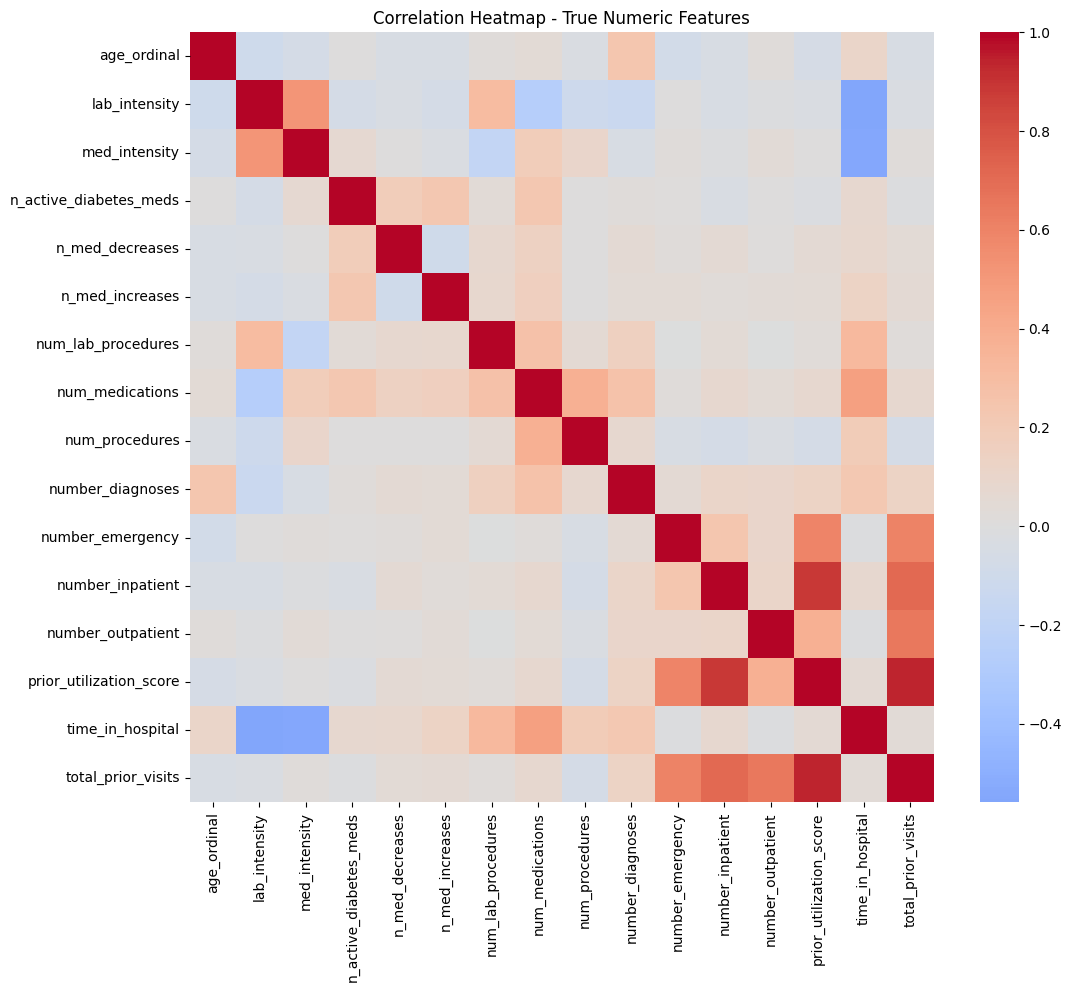

In [7]:
import seaborn as sns
true_numeric_features = [
    "age_ordinal",
    "lab_intensity",
    "med_intensity",
    "n_active_diabetes_meds",
    "n_med_decreases",
    "n_med_increases",
    "num_lab_procedures",
    "num_medications",
    "num_procedures",
    "number_diagnoses",
    "number_emergency",
    "number_inpatient",
    "number_outpatient",
    "prior_utilization_score",
    "time_in_hospital",
    "total_prior_visits",
]

X_train_numeric = X_train[true_numeric_features].copy()

corr_matrix = X_train_numeric.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - True Numeric Features")
plt.show()




In [8]:
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            high_corr_pairs.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_value)
            )

high_corr_pairs

[('prior_utilization_score', 'number_inpatient', 0.884806233769572),
 ('total_prior_visits', 'number_inpatient', 0.7119467486068509),
 ('total_prior_visits', 'prior_utilization_score', 0.9409738454852385)]

In [9]:
temp_df=X_train.copy()
temp_df['target_30day_readmit']=y_train 
temp_df[['prior_utilization_score','target_30day_readmit']].corr()

,prior_utilization_score,target_30day_readmit
prior_utilization_score,1.000000,0.156781
target_30day_readmit,0.156781,1.000000


### Esentially, these three variables measure the same underlying concept - hisotrical healthcare utilization/ severity of illness

number_inpatient → prior hospitalizations

total_prior_visits → combined emergency + inpatient + outpatient

prior_utilization_score → engineered summary metric

we are goign to keep prior_utilization_score because it has been engineered to integrate inpatient, outpatient and emergency visits, making it more informative than a single count variable

# WE DROP TOTAL_PRIOR_VISITS

In [10]:
X_train = X_train.drop(columns=["total_prior_visits"])
X_test_processed = X_test_processed.drop(columns=["total_prior_visits"])

# VIF ANALYSIS FOR CORRELATION

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

numeric_features = [
    "age_ordinal",
    "lab_intensity",
    "med_intensity",
    "n_active_diabetes_meds",
    "n_med_decreases",
    "n_med_increases",
    "num_lab_procedures",
    "num_medications",
    "num_procedures",
    "number_diagnoses",
    "number_emergency",
    "number_inpatient",
    "number_outpatient",
    "prior_utilization_score",
    "time_in_hospital"
]

X_vif = X_train[numeric_features].copy()

vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df = vif_df.sort_values("VIF", ascending=False)

vif_df

/Users/bhavanasanghi/Desktop/hospital-readmission-risk/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
10,number_emergency,inf
11,number_inpatient,inf
12,number_outpatient,inf
13,prior_utilization_score,inf
9,number_diagnoses,15.066471
6,num_lab_procedures,14.185170
7,num_medications,14.096416
0,age_ordinal,12.410915
2,med_intensity,8.988646
14,time_in_hospital,8.964080


## Prior_utilization_score is the best representation of number_emergency, number_inpatient and number_outpatient. lets just keep prior_utilization_score

# DROPPING number_emergency, number_inpatient, number_outpatient

In [12]:
cols_to_drop = [
    "number_emergency",
    "number_inpatient",
    "number_outpatient"
]

X_train = X_train.drop(columns=cols_to_drop)
X_test_processed = X_test_processed.drop(columns=cols_to_drop)

In [13]:
numeric_features = [
    "age_ordinal",
    "lab_intensity",
    "med_intensity",
    "n_active_diabetes_meds",
    "n_med_decreases",
    "n_med_increases",
    "num_lab_procedures",
    "num_medications",
    "num_procedures",
    "number_diagnoses",
    "prior_utilization_score",
    "time_in_hospital"
]

X_vif = X_train[numeric_features].copy()

vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df = vif_df.sort_values("VIF", ascending=False)

vif_df

,feature,VIF
9,number_diagnoses,15.040724
6,num_lab_procedures,14.181558
7,num_medications,14.084079
0,age_ordinal,12.375218
2,med_intensity,8.987395
11,time_in_hospital,8.933987
1,lab_intensity,8.517980
3,n_active_diabetes_meds,2.984998
8,num_procedures,1.953856
10,prior_utilization_score,1.346755


### Regenerating Scaled Training and Test Data

After removing redundant utilization variables identified during the multicollinearity analysis, the feature matrix has changed. 

Because scaling parameters depend on the feature set, we must **refit the scaler on the updated training data** and apply the same transformation to the test data.


In [14]:
numeric_features = [
    "age_ordinal",
    "lab_intensity",
    "med_intensity",
    "n_active_diabetes_meds",
    "n_med_decreases",
    "n_med_increases",
    "num_lab_procedures",
    "num_medications",
    "num_procedures",
    "number_diagnoses",
    "prior_utilization_score",
    "time_in_hospital"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test_processed.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test_scaled[numeric_features] = scaler.transform(
    X_test[numeric_features]
)


In [15]:
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (79538, 79)
Test shape: (19802, 79)


# Baseline Model: Logistic Regression

As a first baseline model, we fit a logistic regression classifier to predict
30-day hospital readmission.

The model is first fit **without regularization** to establish a purely
data-driven baseline.


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from src.evaluate import compute_train_test_metrics, compute_cv_auc

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg = LogisticRegression(
    penalty=None,
    max_iter=5000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train.values.ravel())

# Train/Test metrics
baseline_train_test_df = compute_train_test_metrics(
    model=log_reg,
    X_train=X_train_scaled,
    y_train=y_train.values.ravel(),
    X_test=X_test_scaled,
    y_test=y_test,
    threshold=0.5,
)

# Cross-validation AUC
baseline_cv = compute_cv_auc(
    model=LogisticRegression(
        penalty=None,
        max_iter=5000,
        random_state=42
    ),
    X=X_train_scaled,
    y=y_train.values.ravel(),
    cv=cv,
)

print(baseline_cv)
baseline_train_test_df

{'cv_auc_mean': 0.6604911800780062, 'cv_auc_std': 0.0022603336759025473}


,Split,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Train,0.5,0.885438,0.455696,0.007914,0.015557,0.665856
1,Test,0.5,0.887587,0.424242,0.012635,0.024540,0.660701


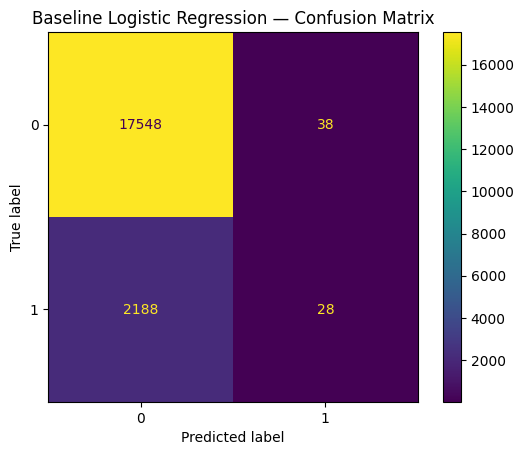

In [71]:
from src.evaluate import plot_confusion_matrix_from_preds

y_pred_test = log_reg.predict(X_test_scaled)
y_test_proba_baseline = log_reg.predict_proba(X_test_scaled)[:,1]

plot_confusion_matrix_from_preds(
    y_test,
    y_pred_test,
    title="Baseline Logistic Regression — Confusion Matrix"
)

In [18]:
# y_pred = log_reg.pedict(X_test_scaled)
# y_pred_proba = log_reg.predict_proba(X_test_scaled)[:,1]

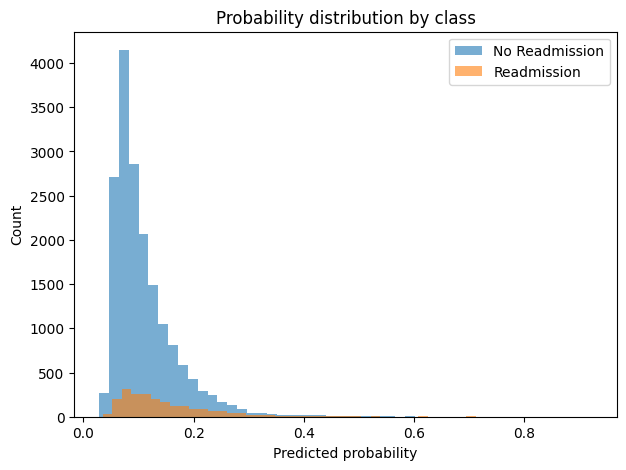

In [72]:
plt.figure(figsize=(7,5))

plt.hist(
    y_test_proba_baseline[y_test==0],
    bins=50,
    alpha=0.6,
    label="No Readmission"
)

plt.hist(
    y_test_proba_baseline[y_test==1],
    bins=50,
    alpha=0.6,
    label="Readmission"
)

plt.legend()

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Probability distribution by class")

plt.show()

The model has moderate discriminatory power but heavy class overlap. The score distribution is compressed toward the lower range

## Threshold tuning baseline logistic regression model because our dataset is imbalanced

## Threshold tuning the baseline via precision-recall analysis

In [73]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba_baseline = cross_val_predict(
    log_reg,
    X_train_scaled,
    y_train.values.ravel(),
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)

rows = []

for t in thresholds:
    y_pred = (oof_proba_baseline >= t).astype(int)

    rows.append({
        "threshold": t,
        "precision": precision_score(y_train, y_pred, zero_division=0),
        "recall": recall_score(y_train, y_pred),
        "f1": f1_score(y_train, y_pred)
    })

threshold_df_baseline = pd.DataFrame(rows)

best_row_baseline = threshold_df_baseline.loc[threshold_df_baseline["f1"].idxmax()]
best_threshold_baseline = best_row_baseline["threshold"]

print("Best OOF threshold for baseline logistic:", round(best_threshold_baseline, 4))
display(best_row_baseline.to_frame().T.round(4))

Best OOF threshold for baseline logistic: 0.138


,threshold,precision,recall,f1
26,0.138,0.2021,0.4357,0.2761


In [74]:
y_pred_tuned = (y_test_proba_baseline >= best_threshold_baseline).astype(int)

from sklearn.metrics import classification_report

print("Threshold used:", best_threshold_baseline)

print(classification_report(y_test, y_pred_tuned))

Threshold used: 0.13804020100502515
              precision    recall  f1-score   support

           0       0.92      0.78      0.84     17586
           1       0.20      0.44      0.27      2216

    accuracy                           0.74     19802
   macro avg       0.56      0.61      0.56     19802
weighted avg       0.84      0.74      0.78     19802



In [75]:
from src.evaluate import evaluate_at_threshold

y_train_proba_baseline = log_reg.predict_proba(X_train_scaled)[:,1] 


train_metrics = evaluate_at_threshold(
    y_true=y_train.values.ravel(),
    y_proba=y_train_proba_baseline,
    threshold=best_threshold_baseline
)

test_metrics = evaluate_at_threshold(
    y_true=y_test,
    y_proba=y_test_proba_baseline,
    threshold=best_threshold_baseline
)

threshold_results_df = pd.DataFrame([
    {"Split": "Train", **train_metrics},
    {"Split": "Test", **test_metrics}
])

threshold_results_df.round(4)

,Split,accuracy,precision,recall,f1,roc_auc,threshold
0,Train,0.7390,0.2032,0.4389,0.2778,0.6659,0.138
1,Test,0.7401,0.1984,0.4350,0.2725,0.6607,0.138


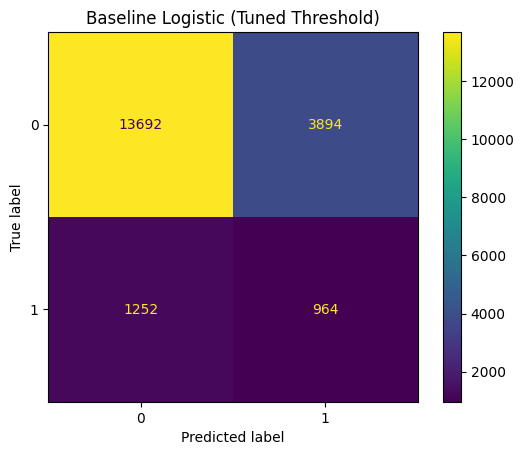

In [76]:
from src.evaluate import plot_confusion_matrix_from_preds

y_pred_tuned_test = (y_test_proba_baseline >= best_threshold_baseline).astype(int)

plot_confusion_matrix_from_preds(
    y_test,
    y_pred_tuned_test,
    title="Baseline Logistic (Tuned Threshold)"
)

The baseline logistic regression model achieved moderate ranking ability (ROC-AUC ≈ 0.66). However, the default classification threshold of 0.5 resulted in extremely low recall.
Threshold tuning using the precision–recall tradeoff identified an optimal threshold around 0.13, increasing recall from 1.8% to approximately 46%, though at the cost of lower precision.
This trade-off is typical for imbalanced healthcare risk prediction tasks where identifying high-risk patients is prioritized over minimizing false alerts.

# Logistic regression model threshold tuned using class_weight param = 'balanced'

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from IPython.display import display

from src.evaluate import compute_train_test_metrics, compute_cv_auc, evaluate_at_threshold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg_balanced = LogisticRegression(
    penalty=None,
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

log_reg_balanced.fit(X_train_scaled, y_train.values.ravel())

balanced_train_test_df = compute_train_test_metrics(
    model=log_reg_balanced,
    X_train=X_train_scaled,
    y_train=y_train.values.ravel(),
    X_test=X_test_scaled,
    y_test=y_test,
    threshold=0.5,
)

balanced_cv = compute_cv_auc(
    model=LogisticRegression(
        penalty=None,
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ),
    X=X_train_scaled,
    y=y_train.values.ravel(),
    cv=cv,
)

display(balanced_train_test_df.round(4))
print({k: round(v, 4) for k, v in balanced_cv.items()})


,Split,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Train,0.5,0.6540,0.1807,0.5729,0.2747,0.6669
1,Test,0.5,0.6548,0.1751,0.5618,0.2670,0.6617


{'cv_auc_mean': 0.6615, 'cv_auc_std': 0.0027}


# Threshold tune this balanced logistic regression model

### Important Note on Probability Scores

class_weight='balanced' inflates the model's probability scores
for the minority class. A score of 0.4 does not mean a 40%
probability of readmission — it means this patient is higher
risk than someone scoring 0.2. Scores reflect relative risk
ranking rather than calibrated probabilities.

This is acceptable for the operational objective of ranking
patients by readmission risk. If calibrated probabilities are
required — for example to calculate expected intervention costs
— Platt Scaling or Isotonic Regression can be applied
post-hoc to recalibrate the scores.

In [78]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba_balanced = cross_val_predict(
    log_reg_balanced,
    X_train_scaled,
    y_train.values.ravel(),
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)

rows = []

for t in thresholds:
    y_pred = (oof_proba_balanced >= t).astype(int)

    rows.append({
        "threshold": t,
        "precision": precision_score(y_train, y_pred, zero_division=0),
        "recall": recall_score(y_train, y_pred),
        "f1": f1_score(y_train, y_pred)
    })

threshold_df_balanced = pd.DataFrame(rows)

best_row_balanced = threshold_df_balanced.loc[threshold_df_balanced["f1"].idxmax()]
best_threshold_balanced = best_row_balanced["threshold"]

print("Best OOF threshold for baseline logistic:", round(best_threshold_balanced, 4))
display(best_row_balanced.to_frame().T.round(4))

Best OOF threshold for baseline logistic: 0.5419


,threshold,precision,recall,f1
108,0.5419,0.1961,0.4655,0.2759


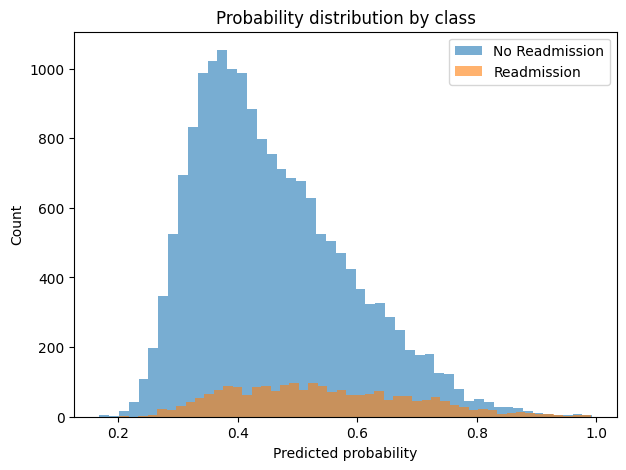

In [79]:
y_pred_test = log_reg_balanced.predict(X_test_scaled)
y_test_proba_balanced = log_reg_balanced.predict_proba(X_test_scaled)[:,1]

plt.figure(figsize=(7,5))

plt.hist(
    y_test_proba_balanced[y_test==0],
    bins=50,
    alpha=0.6,
    label="No Readmission"
)

plt.hist(
    y_test_proba_balanced[y_test==1],
    bins=50,
    alpha=0.6,
    label="Readmission"
)

plt.legend()

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Probability distribution by class")

plt.show()

In [81]:
y_train_proba_balanced = log_reg_balanced.predict_proba(X_train_scaled)[:,1]

balanced_tuned_train_metrics = evaluate_at_threshold(
    y_true=y_train.values.ravel(),
    y_proba=y_train_proba_balanced,
    threshold=best_threshold_balanced
)

balanced_tuned_test_metrics = evaluate_at_threshold(
    y_true=y_test,
    y_proba=y_test_proba_balanced,
    threshold=best_threshold_balanced
)

balanced_tuned_results_df = pd.DataFrame([
    {"Split": "Train", **balanced_tuned_train_metrics},
    {"Split": "Test", **balanced_tuned_test_metrics},
])

display(balanced_tuned_results_df.round(4))

,Split,accuracy,precision,recall,f1,roc_auc,threshold
0,Train,0.7208,0.1971,0.4689,0.2776,0.6669,0.5419
1,Test,0.7235,0.1925,0.4603,0.2715,0.6617,0.5419


# Final result of all 4 models together - test results

In [82]:
#baseline model 
baseline_test_metrics = evaluate_at_threshold(
    y_true=y_test,
    y_proba=y_test_proba_baseline,
    threshold=0.5
)

#baseline mode threshold tuning 
baseline_tuned_test_metrics = evaluate_at_threshold(
    y_true=y_test,
    y_proba=y_test_proba_baseline,
    threshold=best_threshold_baseline
)

# balanced model

balanced_test_metrics = evaluate_at_threshold(
    y_true=y_test,
    y_proba=y_test_proba_balanced,
    threshold=0.5
)

#balanced model threshold tuning

balanced_tuned_test_metrics = evaluate_at_threshold(
    y_true=y_test,
    y_proba=y_test_proba_balanced,
    threshold=best_threshold_balanced
)

final_results_df = pd.DataFrame([
    {"Model": "Baseline", **baseline_test_metrics},
    {"Model": "Baseline Tuned", **baseline_tuned_test_metrics},
    {"Model": "Balanced", **balanced_test_metrics},
    {"Model": "Balanced Tuned", **balanced_tuned_test_metrics},

])

display(final_results_df.round(4))

,Model,accuracy,precision,recall,f1,roc_auc,threshold
0,Baseline,0.8876,0.4242,0.0126,0.0245,0.6607,0.5000
1,Baseline Tuned,0.7401,0.1984,0.4350,0.2725,0.6607,0.1380
2,Balanced,0.6548,0.1751,0.5618,0.2670,0.6617,0.5000
3,Balanced Tuned,0.7235,0.1925,0.4603,0.2715,0.6617,0.5419


# Model Comparison — Logistic Regression Variants

All four models share identical AUC (~0.66) — confirming that
class weighting and threshold adjustment change the operating
point without altering underlying discriminative ability.

The baseline model (threshold=0.5, no class weight) achieves
near-zero recall — clinically useless despite 88.8% accuracy.

Baseline tuned and balanced tuned are nearly identical with their results. they are also more balanced in their recall and precision scores compared to the baseline and balanced models without threshold tuning.

Out of the two models Baseline and Balanced logistic regression, we pick the balanced logistic regression model for its higher predictive ability (better roc-auc score)

In terms of business context, since we are predicting 30-day hospital readmission risk, the goal is to indentify patients who might get readmitted and for early intervention. That means we would prioritize high recall. 

For the sake of simplicity of this project, I would prioritize F1 metric. But in this special case, since the difference between f1 SCORE OF Baseline tunes (highest F1) and Balanced (with highest recall) is 0.55 only, we will go with balanced since we are close to our goal of getting high recall as well without compromising much on the F1 score

# The final selected model will be Balanced logistic regression

### KS Statistic Analysis - Balanced logistic regression

In addition to precision–recall threshold tuning, we evaluate the model using the **Kolmogorov–Smirnov (KS) statistic**

The KS statistic measures the maximum separation between the cumulative distributions of:

- positive cases (readmitted within 30 days)
- negative cases (not readmitted within 30 days)

KS = TPR - FPR

A higher KS value indicates better discriminatory power. The threshold at which KS is maximized is often used as an alternative operating point for classification


In [83]:
from sklearn.metrics import roc_curve
import numpy as np
import pandas as pd

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_balanced)

ks_values = tpr - fpr
ks_idx = np.argmax(ks_values)

ks_stat = ks_values[ks_idx]
ks_threshold = thresholds[ks_idx]

print("KS statistic:", ks_stat)
print("KS-optimal threshold:", ks_threshold)


KS statistic: 0.23677237924325267
KS-optimal threshold: 0.4705564577410748


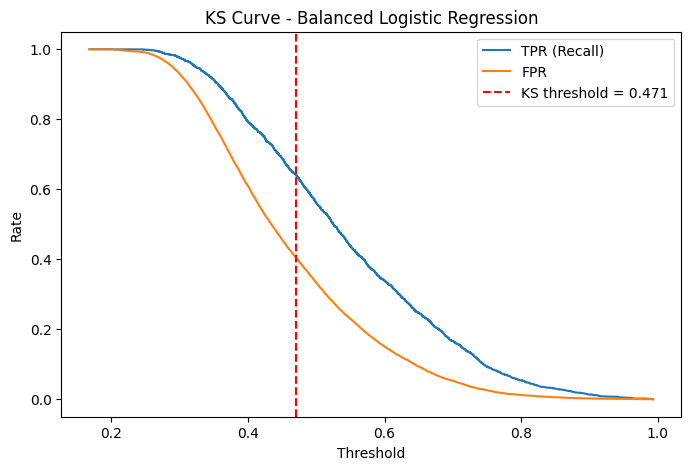

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(thresholds, tpr, label="TPR (Recall)")
plt.plot(thresholds, fpr, label="FPR")
plt.axvline(ks_threshold, color="red", linestyle="--", label=f"KS threshold = {ks_threshold:.3f}")

plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("KS Curve - Balanced Logistic Regression")
plt.legend()
plt.show()

In [85]:
from src.evaluate import evaluate_at_threshold

train_metrics = evaluate_at_threshold(
    y_true=y_train.values.ravel(),
    y_proba=y_train_proba_balanced,
    threshold=ks_threshold
)

test_metrics = evaluate_at_threshold(
    y_true=y_test,
    y_proba=y_test_proba_balanced,
    threshold=ks_threshold
)

threshold_results_df = pd.DataFrame([
    {"Split": "Train", **train_metrics},
    {"Split": "Test", **test_metrics}
])

threshold_results_df.round(4)

,Split,accuracy,precision,recall,f1,roc_auc,threshold
0,Train,0.5991,0.1699,0.6444,0.2689,0.6669,0.4706
1,Test,0.6003,0.1665,0.6417,0.2643,0.6617,0.4706


### Interpretation

The model achieves a **KS statistic of approximately 0.24**, indicating **moderate separation between the two classes**

At the optimal threshold identified, the model captures approximately **64% of readmissions**, demonstrating that it is able to identify a substantial proportion of high-risk patients. While precision remains relatively low due to the inherent class imbalance and overlap between classes, the model provides meaningful discriminatory signal.


# Lift and Decile Analysis

In [86]:

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# Build dataframe with true labels and predicted probabilities
# -----------------------------------
lift_df = pd.DataFrame({
    "y_true": y_test,
    "prob": y_test_proba_balanced
})

# -----------------------------------
# Create deciles based on predicted probability
# qcut creates 10 equally sized bins based on score
# We reverse the numbering so Decile 1 = highest risk
# -----------------------------------
lift_df["decile_raw"] = pd.qcut(
    lift_df["prob"],
    q=10,
    labels=False,
    duplicates="drop"
)

lift_df["decile"] = lift_df["decile_raw"].max() - lift_df["decile_raw"] + 1

# -----------------------------------
# Summarize each decile
# -----------------------------------
decile_summary = lift_df.groupby("decile").agg(
    total_cases=("y_true", "count"),
    readmissions=("y_true", "sum")
)

decile_summary["readmission_rate"] = (
    decile_summary["readmissions"] / decile_summary["total_cases"]
)

# -----------------------------------
# Compute overall readmission rate
# -----------------------------------
overall_rate = lift_df["y_true"].mean()

# -----------------------------------
# Compute lift
# -----------------------------------
decile_summary["lift"] = (
    decile_summary["readmission_rate"] / overall_rate
)

# Sort from highest-risk decile to lowest-risk decile
decile_summary = decile_summary.sort_index()

print("Overall readmission rate:", overall_rate)
display(decile_summary)


Overall readmission rate: 0.11190788809211191


,total_cases,readmissions,readmission_rate,lift
decile,,,,
1,1981,514,0.259465,2.318558
2,1980,311,0.157071,1.403571
3,1980,278,0.140404,1.254639
4,1980,242,0.122222,1.092168
5,1980,214,0.108081,0.965802
6,1980,158,0.079798,0.713068
7,1980,168,0.084848,0.758199
8,1980,139,0.070202,0.627320
9,1980,108,0.054545,0.487414


,readmissions,cum_capture_rate
decile,,
1,514,0.231949
2,311,0.372292
3,278,0.497744
4,242,0.606949
5,214,0.703520
6,158,0.774819
7,168,0.850632
8,139,0.913357
9,108,0.962094


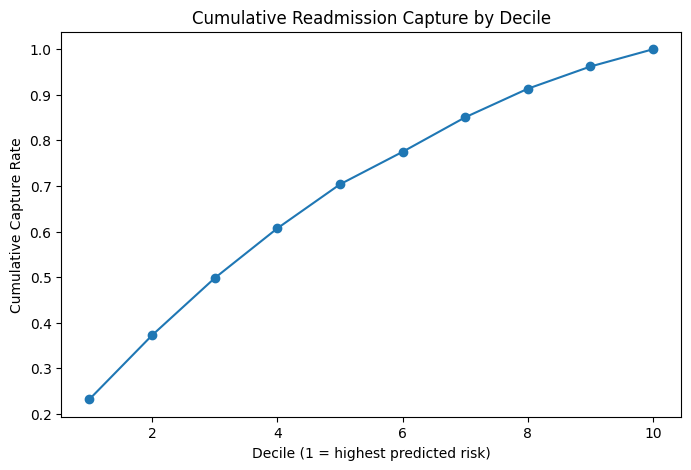

In [87]:
# -----------------------------------
# Cumulative capture of readmissions
# -----------------------------------
decile_summary["cum_readmissions"] = decile_summary["readmissions"].cumsum()
total_readmissions = decile_summary["readmissions"].sum()

decile_summary["cum_capture_rate"] = (
    decile_summary["cum_readmissions"] / total_readmissions
)

display(decile_summary[["readmissions", "cum_capture_rate"]])

plt.figure(figsize=(8, 5))
plt.plot(decile_summary.index, decile_summary["cum_capture_rate"], marker="o")
plt.xlabel("Decile (1 = highest predicted risk)")
plt.ylabel("Cumulative Capture Rate")
plt.title("Cumulative Readmission Capture by Decile")
plt.show()


The model successfully concentrates readmission events within the higher-risk groups. Notably:

- The **top 10% of patients capture approximately 23% of all readmissions**.
- The **top 30% of patients capture approximately 50% of readmissions**.
- The **top 40% of patients capture approximately 61% of readmissions**.

This demonstrates that the model is able to **rank patients by risk effectively**, even though individual predictions remain imperfect.

# Regularized Logistic Regression

Logistic regression in scikit-learn includes L2 (Ridge) regularization by default. However, the regularization parameter was not tuned in the baseline model.

To improve model stability and generalization, we perform **cross-validated hyperparameter tuning** for:

- **Ridge logistic regression (L2 penalty)**  
- **Lasso logistic regression (L1 penalty)**  


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

C_values = np.logspace(-3, 2, 10)   # 0.001 to 100
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

# Ridge (L2)
for C in C_values:
    model = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train.values.ravel(),
        cv=cv,
        scoring="roc_auc"
    )

    results.append({
        "penalty": "L2 (Ridge)",
        "C": C,
        "mean_auc": scores.mean(),
        "std_auc": scores.std()
    })

# Lasso (L1)
for C in C_values:
    model = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train.values.ravel(),
        cv=cv,
        scoring="roc_auc"
    )

    results.append({
        "penalty": "L1 (Lasso)",
        "C": C,
        "mean_auc": scores.mean(),
        "std_auc": scores.std()
    })

results_df = pd.DataFrame(results)

# Best overall model
best_row = results_df.loc[results_df["mean_auc"].idxmax()]

print("Best penalty:", best_row["penalty"])
print("Best C:", best_row["C"])
print(f"Best CV AUC: {best_row['mean_auc']:.4f} ± {best_row['std_auc']:.4f}")

results_df.sort_values(["penalty", "C"])


Best penalty: L1 (Lasso)
Best C: 0.046415888336127795
Best CV AUC: 0.6623 ± 0.0025


,penalty,C,mean_auc,std_auc
10,L1 (Lasso),0.001000,0.649010,0.002558
11,L1 (Lasso),0.003594,0.654323,0.002324
12,L1 (Lasso),0.012915,0.659928,0.003021
13,L1 (Lasso),0.046416,0.662250,0.002470
14,L1 (Lasso),0.166810,0.661960,0.002632
15,L1 (Lasso),0.599484,0.661572,0.002756
16,L1 (Lasso),2.154435,0.661440,0.002801
17,L1 (Lasso),7.742637,0.661401,0.002807
18,L1 (Lasso),27.825594,0.661388,0.002810
19,L1 (Lasso),100.000000,0.661385,0.002810


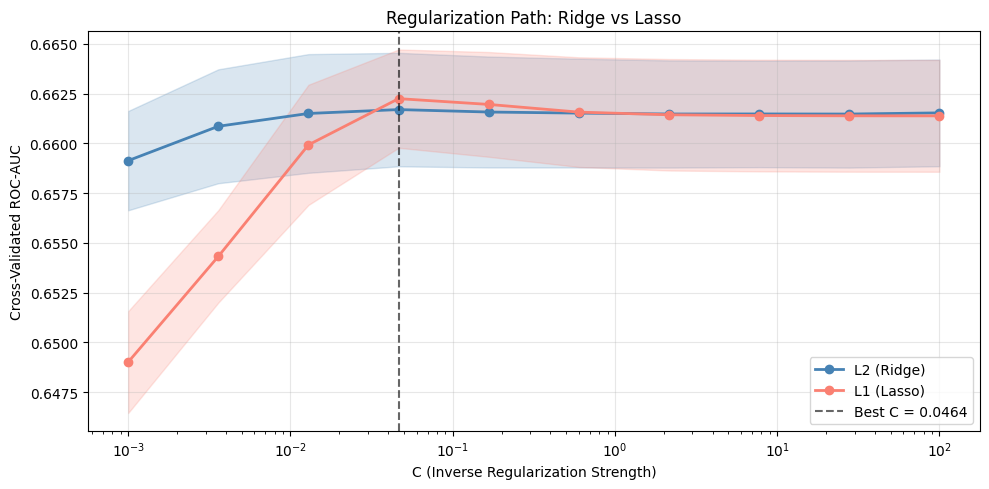

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))

for penalty, color in [("L2 (Ridge)", "steelblue"), ("L1 (Lasso)", "salmon")]:
    subset = results_df[results_df["penalty"] == penalty].sort_values("C")

    ax.semilogx(
        subset["C"],
        subset["mean_auc"],
        marker="o",
        label=penalty,
        color=color,
        linewidth=2
    )

    ax.fill_between(
        subset["C"],
        subset["mean_auc"] - subset["std_auc"],
        subset["mean_auc"] + subset["std_auc"],
        alpha=0.2,
        color=color
    )

ax.axvline(
    best_row["C"],
    color="black",
    linestyle="--",
    alpha=0.6,
    label=f"Best C = {best_row['C']:.3g}"
)

ax.set_xlabel("C (Inverse Regularization Strength)")
ax.set_ylabel("Cross-Validated ROC-AUC")
ax.set_title("Regularization Path: Ridge vs Lasso")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Cross-Validation Results

| Model | Best C | CV AUC |
|------|------|------|
| **L1 (Lasso)** | **0.046** | **0.6623 ± 0.0025** |
| L2 (Ridge) | 0.046 | 0.6617 ± 0.0029 |


### Observations

**1. Lasso slightly outperforms Ridge**

The L1-regularized model achieves the highest cross-validated AUC (~0.6623), although the improvement over Ridge is marginal. This suggests that **some weak predictors may be introducing noise**, and Lasso’s ability to shrink coefficients to zero helps slightly improve generalization.


**2. Performance plateaus after moderate regularization**

For both Ridge and Lasso, model performance improves when moving from very strong regularization (small C) toward moderate regularization, but stabilizes afterwards.

This indicates:

- extremely strong regularization removes useful signal
- weak regularization behaves similarly to standard logistic regression

The optimal region appears around: C=0.046


**3. Multicollinearity is not severely degrading model performance**

Ridge regression typically produces significant improvements when strong multicollinearity exists. However, the Ridge performance curve remains relatively flat across different values of C.

This suggests that the earlier feature engineering steps (removing redundant utilization variables and addressing multicollinearity using VIF analysis) were effective.

**4. Predictive signal in the dataset appears modest**

Even with:

- class imbalance handling (`class_weight='balanced'`)
- threshold tuning
- feature engineering
- regularization

the model’s AUC stabilizes around 0.66


This indicates that the available predictors contain **moderate predictive signal**

### Takeaway

The **L1-regularized logistic regression model (Lasso)** with c = 0.046 is selected








In [88]:
from sklearn.linear_model import LogisticRegression

lasso_log_reg = LogisticRegression(
    penalty="l1",
    C=best_row['C'],
    solver="liblinear",
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

lasso_log_reg.fit(X_train_scaled, y_train.values.ravel())

from src.evaluate import compute_train_test_metrics, compute_cv_auc
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lasso_train_test_df = compute_train_test_metrics(
    model=lasso_log_reg,
    X_train=X_train_scaled,
    y_train=y_train.values.ravel(),
    X_test=X_test_scaled,
    y_test=y_test,
    threshold=0.5
)

lasso_cv = compute_cv_auc(
    model=lasso_log_reg,
    X=X_train_scaled,
    y=y_train.values.ravel(),
    cv=cv
)

display(lasso_train_test_df.round(4))
print({k: round(v,4) for k,v in lasso_cv.items()})



,Split,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Train,0.5,0.6545,0.1808,0.5722,0.2748,0.6666
1,Test,0.5,0.6567,0.1763,0.5632,0.2685,0.6618


{'cv_auc_mean': 0.6623, 'cv_auc_std': 0.0025}


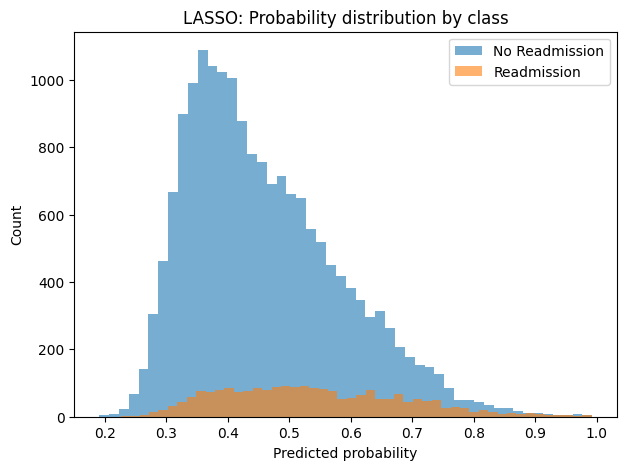

In [89]:
import matplotlib.pyplot as plt

# LASSO predicted probabilities
y_test_proba_lasso = lasso_log_reg.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(7,5))

plt.hist(
    y_test_proba_lasso[y_test == 0],
    bins=50,
    alpha=0.6,
    label="No Readmission"
)

plt.hist(
    y_test_proba_lasso[y_test == 1],
    bins=50,
    alpha=0.6,
    label="Readmission"
)

plt.legend()
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("LASSO: Probability distribution by class")
plt.show()

## To compare our selected balanced model from above and the regularized model

In [90]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from src.evaluate import compute_train_test_metrics, compute_cv_auc

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Balanced Logistic": log_reg_balanced,
    "LASSO Logistic": lasso_log_reg
}

all_results = []

for model_name, model in models.items():
    # train/test metrics
    train_test_df = compute_train_test_metrics(
        model=model,
        X_train=X_train_scaled,
        y_train=y_train.values.ravel(),
        X_test=X_test_scaled,
        y_test=y_test,
        threshold=0.5
    )
    
    # CV metrics
    cv_results = compute_cv_auc(
        model=model,
        X=X_train_scaled,
        y=y_train.values.ravel(),
        cv=cv
    )
    
    # add model name
    train_test_df = train_test_df.copy()
    train_test_df["model"] = model_name
    train_test_df["cv_mean_auc"] = cv_results["cv_auc_mean"]
    train_test_df["cv_std_auc"] = cv_results["cv_auc_std"]
    
    all_results.append(train_test_df)

comparison_df = pd.concat(all_results, ignore_index=True)

# make model first column
cols = ["model"] + [c for c in comparison_df.columns if c != "model"]
comparison_df = comparison_df[cols]

display(comparison_df.round(4))

,model,Split,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,cv_mean_auc,cv_std_auc
0,Balanced Logistic,Train,0.5,0.6540,0.1807,0.5729,0.2747,0.6669,0.6615,0.0027
1,Balanced Logistic,Test,0.5,0.6548,0.1751,0.5618,0.2670,0.6617,0.6615,0.0027
2,LASSO Logistic,Train,0.5,0.6545,0.1808,0.5722,0.2748,0.6666,0.6623,0.0025
3,LASSO Logistic,Test,0.5,0.6567,0.1763,0.5632,0.2685,0.6618,0.6623,0.0025


## From the above results, we can see that lasso and balanced logistic regression have marginal difference. But after Lasso removed features (which will be shown below) the performance is still almost the same as having the entire dataset. So, the features dropped my lasso truly dont contribute to model performance as much. Since lasso model is sparse, interpretable and almost the same performance, we can pick lasso model as our best model in the linear model family

In [91]:
lasso_coefficients = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coef": lasso_log_reg.coef_[0]
})

lasso_coefficients["abs_coef"] = lasso_coefficients["coef"].abs()

lasso_coefficients.sort_values("abs_coef", ascending=False).head(20)

,feature,coef,abs_coef
41,discharge_disposition_Rehab,0.906305,0.906305
39,discharge_disposition_Long_Term_Care,-0.684168,0.684168
37,discharge_disposition_Home,-0.379162,0.379162
15,any_prior_inpatient,0.319752,0.319752
44,discharge_disposition_Unknown,0.315861,0.315861
47,medical_specialty_group_Nephrology,0.314941,0.314941
68,diag_2_category_Neoplasms,0.292335,0.292335
18,prior_utilization_score,0.285978,0.285978
53,medical_specialty_group_Specialty_Medicine,0.240619,0.240619
43,discharge_disposition_Transfer,0.237395,0.237395


In [92]:
# Features zeroed out by Lasso
zeroed_features = lasso_coefficients[lasso_coefficients["coef"] == 0]
active_features = lasso_coefficients[lasso_coefficients["coef"] != 0]

print(f"Total features: {len(lasso_coefficients)}")
print(f"Active features: {len(active_features)}")
print(f"Zeroed by Lasso: {len(zeroed_features)}")

print("\nZeroed features:")
print(zeroed_features["feature"].tolist())

Total features: 79
Active features: 62
Zeroed by Lasso: 17

Zeroed features:
['change', 'race_Asian', 'race_Hispanic', 'race_Other', 'A1Cresult_Norm', 'admission_type_Emergency', 'admission_type_Other', 'admission_type_Unknown', 'admission_source_Other', 'discharge_disposition_Skilled_Nursing', 'medical_specialty_group_Radiology', 'medical_specialty_group_Surgery', 'diag_2_category_Digestive', 'diag_2_category_Injury', 'diag_3_category_Injury', 'diag_3_category_Musculoskeletal', 'diag_3_category_Respiratory']


In [93]:
coef_df = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": lasso_log_reg.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])

nonzero_coef_df = coef_df[coef_df["coefficient"] != 0].copy()

print("Top positive features:")
display(
    nonzero_coef_df.sort_values("coefficient", ascending=False)
    [["feature", "coefficient", "odds_ratio"]]
    .head(15)
    .round(4)
)

print("Top negative features:")
display(
    nonzero_coef_df.sort_values("coefficient", ascending=True)
    [["feature", "coefficient", "odds_ratio"]]
    .head(15)
    .round(4)
)

Top positive features:


,feature,coefficient,odds_ratio
41,discharge_disposition_Rehab,0.9063,2.4752
15,any_prior_inpatient,0.3198,1.3768
44,discharge_disposition_Unknown,0.3159,1.3714
47,medical_specialty_group_Nephrology,0.3149,1.3702
68,diag_2_category_Neoplasms,0.2923,1.3396
18,prior_utilization_score,0.2860,1.3311
53,medical_specialty_group_Specialty_Medicine,0.2406,1.2720
43,discharge_disposition_Transfer,0.2374,1.2679
7,diabetesMed,0.1974,1.2183
50,medical_specialty_group_Primary_Care,0.1394,1.1496


Top negative features:


,feature,coefficient,odds_ratio
39,discharge_disposition_Long_Term_Care,-0.6842,0.5045
37,discharge_disposition_Home,-0.3792,0.6844
62,diag_1_category_Respiratory,-0.1950,0.8228
38,discharge_disposition_Home_Health,-0.1874,0.8291
59,diag_1_category_Musculoskeletal,-0.1470,0.8633
26,race_Unknown,-0.1181,0.8886
48,medical_specialty_group_Orthopedics,-0.1125,0.8936
56,diag_1_category_Digestive,-0.1040,0.9012
36,admission_source_Transfer,-0.0921,0.9120
17,any_prior_outpatient,-0.0747,0.9280


In [94]:
lasso_coef_summary = nonzero_coef_df.sort_values("abs_coefficient", ascending=False)[
    ["feature", "coefficient", "odds_ratio", "abs_coefficient"]
].reset_index(drop=True)

display(lasso_coef_summary.round(4))

OUTPUTS_DIR = PROJECT_ROOT / "outputs"

lasso_coef_summary.to_csv(f"{OUTPUTS_DIR}/tables/lasso_nonzero_coefficients.csv", index=False)


,feature,coefficient,odds_ratio,abs_coefficient
0,discharge_disposition_Rehab,0.9063,2.4752,0.9063
1,discharge_disposition_Long_Term_Care,-0.6842,0.5045,0.6842
2,discharge_disposition_Home,-0.3792,0.6844,0.3792
3,any_prior_inpatient,0.3198,1.3768,0.3198
4,discharge_disposition_Unknown,0.3159,1.3714,0.3159
5,medical_specialty_group_Nephrology,0.3149,1.3702,0.3149
6,diag_2_category_Neoplasms,0.2923,1.3396,0.2923
7,prior_utilization_score,0.2860,1.3311,0.2860
8,medical_specialty_group_Specialty_Medicine,0.2406,1.2720,0.2406
9,discharge_disposition_Transfer,0.2374,1.2679,0.2374


In [96]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba_lasso = cross_val_predict(
    lasso_log_reg,
    X_train_scaled,
    y_train.values.ravel(),
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
y_train_array = y_train.values.ravel()

threshold_results_lasso = []

for t in thresholds:
    y_pred_t = (oof_proba_lasso >= t).astype(int)
    
    threshold_results_lasso.append({
        "threshold": t,
        "accuracy": accuracy_score(y_train_array, y_pred_t),
        "precision": precision_score(y_train_array, y_pred_t, zero_division=0),
        "recall": recall_score(y_train_array, y_pred_t, zero_division=0),
        "f1": f1_score(y_train_array, y_pred_t, zero_division=0)
    })

threshold_df_lasso = pd.DataFrame(threshold_results_lasso)
display(threshold_df_lasso.round(4))

best_f1_row_lasso = threshold_df_lasso.loc[threshold_df_lasso["f1"].idxmax()]
print(best_f1_row_lasso.round(4))

best_threshold_lasso = best_f1_row_lasso["threshold"]
print("Best OOF threshold for LASSO:", round(best_threshold_lasso, 4))

,threshold,accuracy,precision,recall,f1
0,0.10,0.1144,0.1144,1.0000,0.2053
1,0.11,0.1144,0.1144,1.0000,0.2053
2,0.12,0.1144,0.1144,1.0000,0.2053
3,0.13,0.1144,0.1144,1.0000,0.2053
4,0.14,0.1144,0.1144,1.0000,0.2053
5,0.15,0.1144,0.1144,1.0000,0.2053
6,0.16,0.1144,0.1144,1.0000,0.2053
7,0.17,0.1144,0.1144,1.0000,0.2053
8,0.18,0.1144,0.1144,1.0000,0.2053
9,0.19,0.1144,0.1144,1.0000,0.2053


threshold    0.5300
accuracy     0.7055
precision    0.1913
recall       0.4879
f1           0.2749
Name: 43, dtype: float64
Best OOF threshold for LASSO: 0.53


In [97]:
# y_train_proba_lasso = lasso_log_reg.predict_proba(X_train_scaled)[:, 1]

# thresholds = np.arange(0.10, 0.91, 0.01)
# y_train_array = np.array(y_train).ravel()

# threshold_results_train = []

# for t in thresholds:
#     y_pred_t = (y_train_proba_lasso >= t).astype(int)
    
#     threshold_results_train.append({
#         "threshold": t,
#         "accuracy": accuracy_score(y_train_array, y_pred_t),
#         "precision": precision_score(y_train_array, y_pred_t, zero_division=0),
#         "recall": recall_score(y_train_array, y_pred_t, zero_division=0),
#         "f1": f1_score(y_train_array, y_pred_t, zero_division=0)
#     })

# threshold_df_train = pd.DataFrame(threshold_results_train)
# display(threshold_df_train.round(4))

# best_f1_row = threshold_df_train.loc[threshold_df_train["f1"].idxmax()]
# print(best_f1_row.round(4))

In [98]:
from src.evaluate import compute_train_test_metrics

lasso_test_050 = compute_train_test_metrics(
    model=lasso_log_reg,
    X_train=X_train_scaled,
    y_train=y_train.values.ravel(),
    X_test=X_test_scaled,
    y_test=y_test,
    threshold=0.50
)

lasso_test_053 = compute_train_test_metrics(
    model=lasso_log_reg,
    X_train=X_train_scaled,
    y_train=y_train.values.ravel(),
    X_test=X_test_scaled,
    y_test=y_test,
    threshold=best_f1_row['threshold']
)

lasso_threshold_compare = pd.concat([lasso_test_050, lasso_test_053], ignore_index=True)
display(lasso_threshold_compare.round(4))

,Split,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Train,0.50,0.6545,0.1808,0.5722,0.2748,0.6666
1,Test,0.50,0.6567,0.1763,0.5632,0.2685,0.6618
2,Train,0.53,0.7066,0.1934,0.4937,0.2779,0.6666
3,Test,0.53,0.7078,0.1879,0.4851,0.2709,0.6618


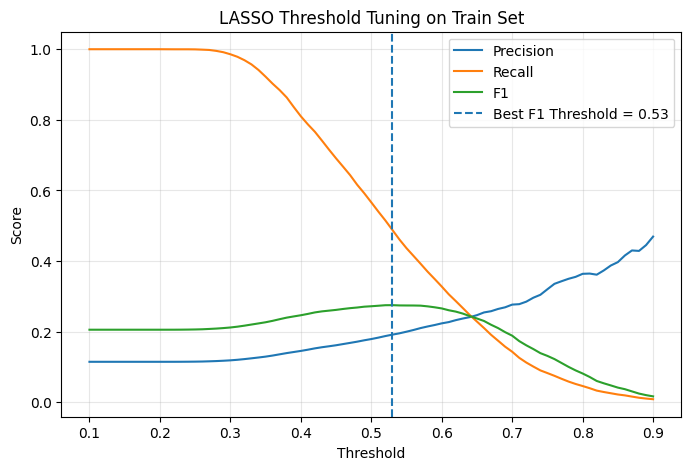

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(threshold_df_lasso["threshold"], threshold_df_lasso["precision"], label="Precision")
plt.plot(threshold_df_lasso["threshold"], threshold_df_lasso["recall"], label="Recall")
plt.plot(threshold_df_lasso["threshold"], threshold_df_lasso["f1"], label="F1")

plt.axvline(0.53, linestyle="--", label="Best F1 Threshold = 0.53")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("LASSO Threshold Tuning on Train Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [100]:
import pandas as pd
import numpy as np

y_test_array = np.array(y_test).ravel()
y_test_proba_lasso = lasso_log_reg.predict_proba(X_test_scaled)[:, 1]

lasso_scored = pd.DataFrame({
    "actual": y_test_array,
    "score": y_test_proba_lasso
})

lasso_scored = lasso_scored.sort_values("score", ascending=False).reset_index(drop=True)
lasso_scored["decile"] = pd.qcut(lasso_scored.index, 10, labels=False) + 1
lasso_scored["decile"] = lasso_scored["decile"].astype(int)

## KS STATISTIC ANALYSIS

In [101]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_lasso)

ks_values = tpr - fpr
ks_idx = np.argmax(ks_values)

ks_stat = ks_values[ks_idx]
ks_threshold_lasso = thresholds[ks_idx]

print("KS statistic:", round(ks_stat, 4))
print("KS-optimal threshold:", round(ks_threshold_lasso, 4))

KS statistic: 0.2375
KS-optimal threshold: 0.468


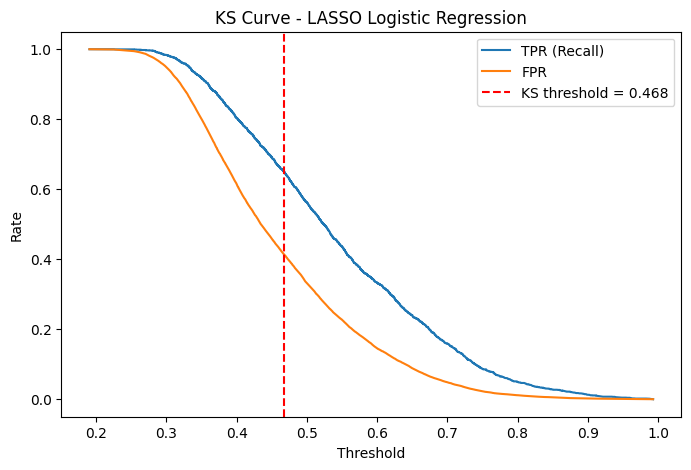

In [102]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, tpr, label="TPR (Recall)")
plt.plot(thresholds, fpr, label="FPR")
plt.axvline(ks_threshold_lasso, color="red", linestyle="--", label=f"KS threshold = {ks_threshold_lasso:.3f}")

plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("KS Curve - LASSO Logistic Regression")
plt.legend()
plt.show()

In [103]:
from src.evaluate import evaluate_at_threshold

y_train_proba_lasso = lasso_log_reg.predict_proba(X_train_scaled)[:, 1]

train_metrics_ks = evaluate_at_threshold(
    y_true=y_train.values.ravel(),
    y_proba=y_train_proba_lasso,
    threshold=ks_threshold_lasso
)

test_metrics_ks = evaluate_at_threshold(
    y_true=y_test,
    y_proba=y_test_proba_lasso,
    threshold=ks_threshold_lasso
)

ks_threshold_results_df = pd.DataFrame([
    {"Split": "Train", **train_metrics_ks},
    {"Split": "Test", **test_metrics_ks}
])

display(ks_threshold_results_df.round(4))

,Split,accuracy,precision,recall,f1,roc_auc,threshold
0,Train,0.5923,0.1684,0.6514,0.2676,0.6666,0.468
1,Test,0.5946,0.1657,0.6498,0.2641,0.6618,0.468


# Finally comparing 5 models - 

1. Balanced log reg
2. Balanced log reg with KS statistic
3. Lasso
4. Lasso with threshold tuning
5. Lasso with KS statistic

In [104]:
from src.evaluate import evaluate_at_threshold


# --- thresholds ---
balanced_ks_threshold = ks_threshold # <-- put your earlier balanced KS threshold here
lasso_ks_threshold = ks_threshold_lasso
lasso_f1_threshold = best_threshold_lasso

# --- helper to make rows ---
def make_threshold_rows(model_name, threshold_name, threshold_value, y_train_true, y_train_proba, y_test_true, y_test_proba):
    train_metrics = evaluate_at_threshold(
        y_true=y_train_true,
        y_proba=y_train_proba,
        threshold=threshold_value
    )
    
    test_metrics = evaluate_at_threshold(
        y_true=y_test_true,
        y_proba=y_test_proba,
        threshold=threshold_value
    )
    
    train_row = {
        "model": model_name,
        "threshold_type": threshold_name,
        "Split": "Train",
        **train_metrics
    }
    
    test_row = {
        "model": model_name,
        "threshold_type": threshold_name,
        "Split": "Test",
        **test_metrics
    }
    
    return [train_row, test_row]

# --- build comparison table ---
rows = []

rows += make_threshold_rows(
    "Balanced Logistic", "Default 0.50", 0.50,
    y_train.values.ravel(), y_train_proba_balanced,
    y_test.values.ravel() if hasattr(y_test, "values") else y_test, y_test_proba_balanced
)

rows += make_threshold_rows(
    "Balanced Logistic", "KS", balanced_ks_threshold,
    y_train.values.ravel(), y_train_proba_balanced,
    y_test.values.ravel() if hasattr(y_test, "values") else y_test, y_test_proba_balanced
)

rows += make_threshold_rows(
    "LASSO Logistic", "Default 0.50", 0.50,
    y_train.values.ravel(), y_train_proba_lasso,
    y_test.values.ravel() if hasattr(y_test, "values") else y_test, y_test_proba_lasso
)

rows += make_threshold_rows(
    "LASSO Logistic", "KS", lasso_ks_threshold,
    y_train.values.ravel(), y_train_proba_lasso,
    y_test.values.ravel() if hasattr(y_test, "values") else y_test, y_test_proba_lasso
)

rows += make_threshold_rows(
    "LASSO Logistic", "Best F1", lasso_f1_threshold,
    y_train.values.ravel(), y_train_proba_lasso,
    y_test.values.ravel() if hasattr(y_test, "values") else y_test, y_test_proba_lasso
)

final_threshold_comparison_df = pd.DataFrame(rows)
display(final_threshold_comparison_df.round(4))

,model,threshold_type,Split,accuracy,precision,recall,f1,roc_auc,threshold
0,Balanced Logistic,Default 0.50,Train,0.6540,0.1807,0.5729,0.2747,0.6669,0.5000
1,Balanced Logistic,Default 0.50,Test,0.6548,0.1751,0.5618,0.2670,0.6617,0.5000
2,Balanced Logistic,KS,Train,0.5991,0.1699,0.6444,0.2689,0.6669,0.4706
3,Balanced Logistic,KS,Test,0.6003,0.1665,0.6417,0.2643,0.6617,0.4706
4,LASSO Logistic,Default 0.50,Train,0.6545,0.1808,0.5722,0.2748,0.6666,0.5000
5,LASSO Logistic,Default 0.50,Test,0.6567,0.1763,0.5632,0.2685,0.6618,0.5000
6,LASSO Logistic,KS,Train,0.5923,0.1684,0.6514,0.2676,0.6666,0.4680
7,LASSO Logistic,KS,Test,0.5946,0.1657,0.6498,0.2641,0.6618,0.4680
8,LASSO Logistic,Best F1,Train,0.7066,0.1934,0.4937,0.2779,0.6666,0.5300
9,LASSO Logistic,Best F1,Test,0.7078,0.1879,0.4851,0.2709,0.6618,0.5300


## Final Linear Model Selection

In a real-world risk modeling scenario, model selection should be guided by both **predictive performance** and the **business objective** of the project.

In this case, the goal is to identify patients at elevated risk of 30-day hospital readmission so that they can be targeted for preventative intervention. Because failing to identify a truly high-risk patient is costly in healthcare settings, **recall is an important consideration**.

However, when comparing different model specifications, it is important to evaluate them under a **consistent evaluation framework**. For this reason, linear models were initially compared using an **F1-optimized threshold**, which provides a balanced trade-off between precision and recall. It was also chosen just for simplicity for this project.

---

## Selected Linear Model: LASSO Logistic Regression

LASSO Logistic Regression was selected as the preferred linear model because its **predictive performance was nearly identical to the balanced logistic regression model**, while producing a **simpler and more interpretable model**.

Specifically, LASSO regularization shrank **17 coefficients to zero**, effectively performing feature selection while maintaining comparable predictive performance.

This makes the model easier to interpret and explain while preserving ranking ability.

---

## Threshold Analysis

After selecting the best linear model, multiple thresholds were evaluated to understand how operational performance changes under different decision policies:

| Threshold Strategy | Purpose |
|---|---|
| Default (0.50) | Standard classification baseline with balanced class weights|
| KS Threshold | Identifies where class separation (TPR − FPR) is maximized |
| F1 Threshold | Provides a balanced trade-off between precision and recall |

The balanced logistic regression was chosen as the primary operating point for comparison because it provides a balanced evaluation framework when comparing models.

It is important to note that **threshold choice represents a policy decision rather than a modeling decision**, and in real-world deployments this threshold would typically be chosen based on operational capacity or intervention cost.

---

## Why KS Threshold Was Not Used as the Primary Operating Point

The KS statistic is useful for **model validation**, as it measures how well the model separates positive and negative classes.

However, the KS-optimal threshold does not incorporate **business considerations such as intervention capacity, cost of false positives, or cost of missed cases**. It simply identifies the point where the difference between true positive rate and false positive rate is maximized.

Therefore, while KS is useful for evaluating model discrimination, it does not directly determine the most appropriate **operational decision threshold**.

---

## Final Linear Model

The final selected linear model for further comparison with non-linear models is:

**LASSO Logistic Regression**

with a class_weight = 'balanced' used as the primary balanced operating point.

This model maintains strong predictive performance while improving interpretability through coefficient shrinkage.

# Lift/Declie table for the final selected model

In [116]:
import pandas as pd
import numpy as np

# predicted probabilities from selected LASSO model
y_test_proba_lasso = lasso_log_reg.predict_proba(X_test_scaled)[:, 1]
y_test_array = np.array(y_test).ravel()

lift_df = pd.DataFrame({
    "y_true": y_test_array,
    "y_proba": y_test_proba_lasso
})

# highest-risk first
lift_df = lift_df.sort_values("y_proba", ascending=False).reset_index(drop=True)

# create deciles
lift_df["decile"] = pd.qcut(
    lift_df.index + 1,
    10,
    labels=[1,2,3,4,5,6,7,8,9,10]
)

decile_summary = lift_df.groupby("decile").agg(
    total=("y_true", "count"),
    positives=("y_true", "sum"),
    avg_score=("y_proba", "mean")
).reset_index()

overall_positive_rate = lift_df["y_true"].mean()

decile_summary["positive_rate"] = decile_summary["positives"] / decile_summary["total"]
decile_summary["lift"] = decile_summary["positive_rate"] / overall_positive_rate

# cumulative gains
decile_summary["cum_positives"] = decile_summary["positives"].cumsum()
decile_summary["cum_positive_pct"] = decile_summary["cum_positives"] / decile_summary["positives"].sum()
decile_summary["cum_population_pct"] = decile_summary["total"].cumsum() / decile_summary["total"].sum()

display(decile_summary.round(4))

/var/folders/4y/hrcfh_wx73xdf5xqhx08gqrc0000gn/T/ipykernel_35778/179041891.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_summary = lift_df.groupby("decile").agg(


,decile,total,positives,avg_score,positive_rate,lift,cum_positives,cum_positive_pct,cum_population_pct
0,1,1981,513,0.7334,0.2590,2.3140,513,0.2315,0.1
1,2,1980,303,0.6145,0.1530,1.3675,816,0.3682,0.2
2,3,1980,288,0.5501,0.1455,1.2998,1104,0.4982,0.3
3,4,1980,239,0.5037,0.1207,1.0786,1343,0.6060,0.4
4,5,1980,218,0.4636,0.1101,0.9839,1561,0.7044,0.5
5,6,1980,170,0.4267,0.0859,0.7672,1731,0.7811,0.6
6,7,1980,151,0.3959,0.0763,0.6815,1882,0.8493,0.7
7,8,1980,135,0.3677,0.0682,0.6093,2017,0.9102,0.8
8,9,1980,114,0.3390,0.0576,0.5145,2131,0.9616,0.9
9,10,1981,85,0.2961,0.0429,0.3834,2216,1.0000,1.0


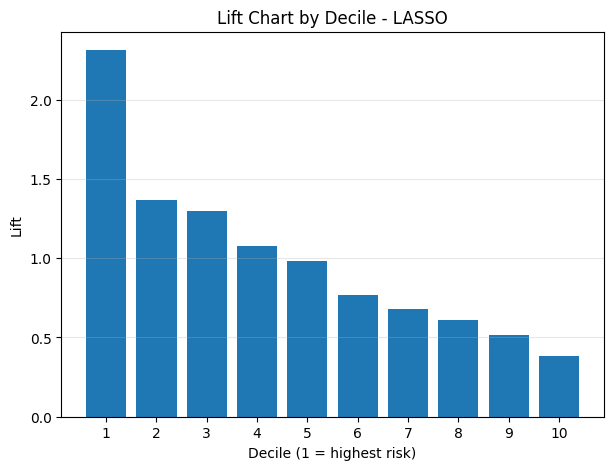

In [117]:
plt.figure(figsize=(7,5))

plt.bar(decile_summary["decile"].astype(str), decile_summary["lift"])

plt.xlabel("Decile (1 = highest risk)")
plt.ylabel("Lift")
plt.title("Lift Chart by Decile - LASSO")
plt.grid(axis="y", alpha=0.3)
plt.show()

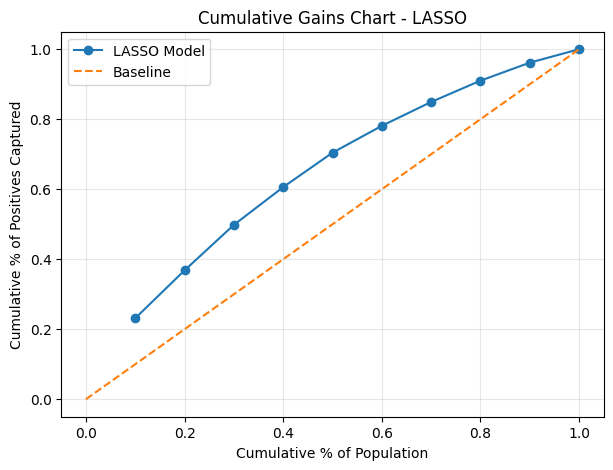

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    decile_summary["cum_population_pct"],
    decile_summary["cum_positive_pct"],
    marker="o",
    label="LASSO Model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Baseline"
)

plt.xlabel("Cumulative % of Population")
plt.ylabel("Cumulative % of Positives Captured")
plt.title("Cumulative Gains Chart - LASSO")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


- The **top 10% highest-risk patients** identified by the model have a readmission rate of **25.9%**, corresponding to a **lift of 2.31×** compared to random selection.
- The **top 20% of patients capture 36.8% of all readmissions**.
- The **top 40% capture nearly 60% of all readmissions**.

This demonstrates that the model successfully concentrates a large proportion of readmission events within the highest predicted risk groups.

### Interpretation

These results indicate that the model provides meaningful **risk stratification capability**. In practice, healthcare systems typically have limited resources for post-discharge interventions. Instead of applying interventions to all patients, the model allows clinicians to **focus attention on the subset of patients with the highest predicted risk**.

For example, targeting the top 20–30% of patients identified by the model could capture a large proportion of potential readmissions while limiting the number of patients requiring intervention.

### Model Selection Justification

The **LASSO Logistic Regression model** was selected as the preferred linear model because:

- It achieved predictive performance comparable to the balanced logistic regression model
- It produced a **simpler and more interpretable model** by shrinking 17 coefficients to zero
- It demonstrated strong **risk ranking ability**, as evidenced by the lift and gains analysis

Because the model is able to effectively prioritize high-risk patients, it aligns well with the project objective of **supporting targeted clinical interventions for preventing hospital readmissions**.

This model therefore serves as the **baseline risk model**, which will next be compared with more flexible machine learning models such as **XGBoost** to determine whether nonlinear methods can further improve risk ranking performance.

In [115]:
import joblib
import json
from pathlib import Path

# create models folder if it doesn't exist
models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(exist_ok=True)

zero_features = list(zeroed_features["feature"])

# choose your final threshold
selected_threshold=0.5

# save trained lasso model
joblib.dump(lasso_log_reg, models_dir / "lasso_log_reg.joblib")

# save scaler
joblib.dump(scaler, models_dir / "scaler.joblib")

# save metadata
model_metadata = {
    "model_name": "LASSO Logistic Regression",
    "penalty": "l1",
    "selected_threshold": selected_threshold,
    "n_features_total": int(len(X_train_scaled.columns)),
    "feature_columns": list(X_train_scaled.columns),
    "zeroed_features": zero_features if "zero_features" in globals() else []
}

with open(models_dir / "lasso_log_reg_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=4)

print("Saved:")
print(models_dir / "lasso_log_reg.joblib")
print(models_dir / "scaler.joblib")
print(models_dir / "lasso_log_reg_metadata.json")

Saved:
/Users/bhavanasanghi/Desktop/hospital-readmission-risk/models/lasso_log_reg.joblib
/Users/bhavanasanghi/Desktop/hospital-readmission-risk/models/scaler.joblib
/Users/bhavanasanghi/Desktop/hospital-readmission-risk/models/lasso_log_reg_metadata.json


---

---

# Training a Baseline XGBoost Model

After completing the linear modeling phase with Logistic Regression and LASSO, the next step is to move to a nonlinear model family. For this, we train an **XGBoost classifier** XGBoost is a strong next choice because it can capture nonlinear relationships and feature interactions. This makes it relevant for a readmission-risk prediction problem, where risk may depend on combinations of utilization, discharge, diagnosis, and demographic features rather than only additive linear effects.

We begin with a **baseline XGBoost model**, not a tuned one. The goal of this step is to establish a strong and defensible nonlinear benchmark before moving into hyperparameter tuning.

### Why these baseline hyperparameters were chosen

- **`objective="binary:logistic"`**  
  This is the standard XGBoost objective for binary classification and returns predicted probabilities for the positive class. It is appropriate because our target is whether a patient is readmitted within 30 days. 

- **`eval_metric="auc"`**  
  We use AUC as the evaluation metric because this is an imbalanced classification problem and we care about ranking high-risk patients correctly, not just raw accuracy. AUC is also consistent with the way we evaluated our earlier logistic models. 

- **`scale_pos_weight = (# negatives / # positives)`**  
  This parameter is used to account for class imbalance by increasing the weight of the minority class during training. In our dataset, 30-day readmissions are much less frequent than non-readmissions, so using `scale_pos_weight` is a standard XGBoost approach for imbalanced binary classification. 

- **`tree_method="hist"`**  
  We use the histogram-based tree method because it is the standard efficient tree-building approach in modern XGBoost and is well suited for tabular modeling. 

- **`n_estimators=1000`**  
  We intentionally allow a large maximum number of boosting rounds so that the model has enough capacity to learn. In practice, the effective number of trees will be controlled later through validation and early stopping, so this value acts as an upper bound rather than a claim that 1000 trees is optimal.

- **`learning_rate=0.05`**  
  A relatively small learning rate is used to make boosting more gradual and stable. This is a common baseline choice because it reduces the chance of overly aggressive updates in early trees.

- **`max_depth=3`**  
  We start with shallow trees to reduce the risk of overfitting and to keep the baseline model conservative. Deeper trees can be explored later during tuning if needed. XGBoost defines `max_depth` as the maximum depth of each tree.

### Modeling note

These hyperparameters were chosen as a **sensible baseline configuration**, not as tuned or optimal values. After establishing baseline XGBoost performance, we will tune the most important tree and regularization parameters and compare the tuned model back against both the baseline XGBoost and the selected LASSO model.

In [52]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train.values.ravel(),
    test_size=0.2,
    stratify=y_train.values.ravel(),
    random_state=42
)

neg = (y_tr == 0).sum()
pos = (y_tr == 1).sum()
scale_pos_weight = neg / pos

xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb_baseline.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
from src.evaluate import compute_train_test_metrics, compute_cv_auc
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_train_test_df = compute_train_test_metrics(
    model=xgb_baseline,
    X_train=X_train,   
    y_train=y_train.values.ravel(),
    X_test=X_test_processed,   
    y_test=y_test,
    threshold=0.50
)

xgb_cv = compute_cv_auc(
    model=xgb_baseline,
    X=X_train,
    y=y_train.values.ravel(),
    cv=cv
)

display(xgb_train_test_df.round(4))
print({k: round(v, 4) for k, v in xgb_cv.items()})

,Split,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Train,0.5,0.6697,0.2026,0.6431,0.3082,0.7208
1,Test,0.5,0.6545,0.1775,0.5745,0.2712,0.6607


{'cv_auc_mean': 0.6653, 'cv_auc_std': 0.0034}


# Running grid search hyperparameter tuning on XGBOOST model

In [58]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import numpy as np
import pandas as pd

# use your FINAL unscaled train matrix here
X_train_xgb = X_train
y_train_xgb = y_train.values.ravel()

neg = (y_train_xgb == 0).sum()
pos = (y_train_xgb == 1).sum()
scale_pos_weight = neg / pos

print("scale_pos_weight:", round(scale_pos_weight, 4))

xgb_tune_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

param_dist = {
    "n_estimators": [200, 400, 600, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [3, 5, 7, 10],
    "gamma": [0, 0.1, 0.3, 0.5, 1.0],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [1, 2, 5, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_random = RandomizedSearchCV(
    estimator=xgb_tune_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    refit=True,
    return_train_score=True
)

xgb_random.fit(X_train_xgb, y_train_xgb)

print("Best CV AUC:", round(xgb_random.best_score_, 4))
print("Best params:")
print(xgb_random.best_params_)

best_xgb = xgb_random.best_estimator_

scale_pos_weight: 7.7424
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV AUC: 0.67
Best params:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1.0, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.8}


In [59]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_tuned_train_test_df = compute_train_test_metrics(
    model=best_xgb,
    X_train=X_train,
    y_train=y_train.values.ravel(),
    X_test=X_test_processed,
    y_test=y_test,
    threshold=0.5
)

xgb_tuned_cv = compute_cv_auc(
    model=best_xgb,
    X=X_train,
    y=y_train.values.ravel(),
    cv=cv
)

display(xgb_tuned_train_test_df.round(4))
print({k: round(v, 4) for k, v in xgb_tuned_cv.items()})

,Split,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Train,0.5,0.6531,0.1937,0.6429,0.2977,0.7094
1,Test,0.5,0.6442,0.1761,0.5925,0.2715,0.6675


{'cv_auc_mean': 0.67, 'cv_auc_std': 0.0027}


In [122]:
from src.evaluate import compute_train_test_metrics, compute_cv_auc
from sklearn.model_selection import StratifiedKFold
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = [
    {
        "model_name": "Selected LASSO",
        "model": lasso_log_reg,
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "threshold": 0.50  
    },
    {
        "model_name": "Tuned XGBoost",
        "model": best_xgb,
        "X_train": X_train,
        "X_test": X_test_processed,
        "threshold": 0.50  
    }
]

all_results = []

for item in models:
    train_test_df = compute_train_test_metrics(
        model=item["model"],
        X_train=item["X_train"],
        y_train=y_train.values.ravel(),
        X_test=item["X_test"],
        y_test=y_test,
        threshold=item["threshold"]
    )

    cv_results = compute_cv_auc(
        model=item["model"],
        X=item["X_train"],
        y=y_train.values.ravel(),
        cv=cv
    )

    train_test_df = train_test_df.copy()
    train_test_df["model"] = item["model_name"]
    train_test_df["cv_mean_auc"] = cv_results["cv_auc_mean"]
    train_test_df["cv_std_auc"] = cv_results["cv_auc_std"]

    all_results.append(train_test_df)

final_model_comparison_df = pd.concat(all_results, ignore_index=True)

cols = ["model"] + [c for c in final_model_comparison_df.columns if c != "model"]
final_model_comparison_df = final_model_comparison_df[cols]

display(final_model_comparison_df.round(4))

,model,Split,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,cv_mean_auc,cv_std_auc
0,Selected LASSO,Train,0.5,0.6545,0.1808,0.5722,0.2748,0.6666,0.6623,0.0025
1,Selected LASSO,Test,0.5,0.6567,0.1763,0.5632,0.2685,0.6618,0.6623,0.0025
2,Tuned XGBoost,Train,0.5,0.6531,0.1937,0.6429,0.2977,0.7094,0.6700,0.0027
3,Tuned XGBoost,Test,0.5,0.6442,0.1761,0.5925,0.2715,0.6675,0.6700,0.0027


### Key Observations

The tuned XGBoost model achieved a **higher test ROC-AUC (0.6675)** compared to the LASSO model (0.6618), indicating a modest improvement in the model’s ability to rank patients by readmission risk.

Recall also improved from **0.563 to 0.593**, meaning that the XGBoost model is able to identify a larger proportion of patients who will ultimately be readmitted.

Importantly, this increase in recall did **not come with a meaningful drop in precision**, which remained approximately the same across both models.


### Interpretation

Although the performance gain is modest, XGBoost provides a measurable improvement in the model’s ability to prioritize high-risk patients. 
Therefore, the tuned XGBoost model is selected as the **final predictive model**, while the LASSO model serves as a strong and interpretable linear benchmark.

# Lift/Decile Analysis 

In [123]:
import pandas as pd
import numpy as np

# predicted probabilities from tuned XGBoost
y_test_proba_xgb = best_xgb.predict_proba(X_test_processed)[:, 1]
y_test_array = np.array(y_test).ravel()

xgb_lift_df = pd.DataFrame({
    "y_true": y_test_array,
    "y_proba": y_test_proba_xgb
})

# highest-risk first
xgb_lift_df = xgb_lift_df.sort_values("y_proba", ascending=False).reset_index(drop=True)

# create deciles
xgb_lift_df["decile"] = pd.qcut(
    xgb_lift_df.index + 1,
    10,
    labels=[1,2,3,4,5,6,7,8,9,10]
)

xgb_decile_summary = xgb_lift_df.groupby("decile").agg(
    total=("y_true", "count"),
    positives=("y_true", "sum"),
    avg_score=("y_proba", "mean")
).reset_index()

overall_positive_rate = xgb_lift_df["y_true"].mean()

xgb_decile_summary["positive_rate"] = xgb_decile_summary["positives"] / xgb_decile_summary["total"]
xgb_decile_summary["lift"] = xgb_decile_summary["positive_rate"] / overall_positive_rate

# cumulative gains
xgb_decile_summary["cum_positives"] = xgb_decile_summary["positives"].cumsum()
xgb_decile_summary["cum_positive_pct"] = xgb_decile_summary["cum_positives"] / xgb_decile_summary["positives"].sum()
xgb_decile_summary["cum_population_pct"] = xgb_decile_summary["total"].cumsum() / xgb_decile_summary["total"].sum()

display(xgb_decile_summary.round(4))

/var/folders/4y/hrcfh_wx73xdf5xqhx08gqrc0000gn/T/ipykernel_35778/3370669758.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  xgb_decile_summary = xgb_lift_df.groupby("decile").agg(


,decile,total,positives,avg_score,positive_rate,lift,cum_positives,cum_positive_pct,cum_population_pct
0,1,1981,531,0.7145,0.2680,2.3952,531,0.2396,0.1
1,2,1980,312,0.6102,0.1576,1.4081,843,0.3804,0.2
2,3,1980,276,0.5540,0.1394,1.2456,1119,0.5050,0.3
3,4,1980,250,0.5112,0.1263,1.1283,1369,0.6178,0.4
4,5,1980,200,0.4686,0.1010,0.9026,1569,0.7080,0.5
5,6,1980,165,0.4269,0.0833,0.7447,1734,0.7825,0.6
6,7,1980,146,0.3886,0.0737,0.6589,1880,0.8484,0.7
7,8,1980,143,0.3506,0.0722,0.6454,2023,0.9129,0.8
8,9,1980,110,0.3080,0.0556,0.4964,2133,0.9625,0.9
9,10,1981,83,0.2375,0.0419,0.3744,2216,1.0000,1.0


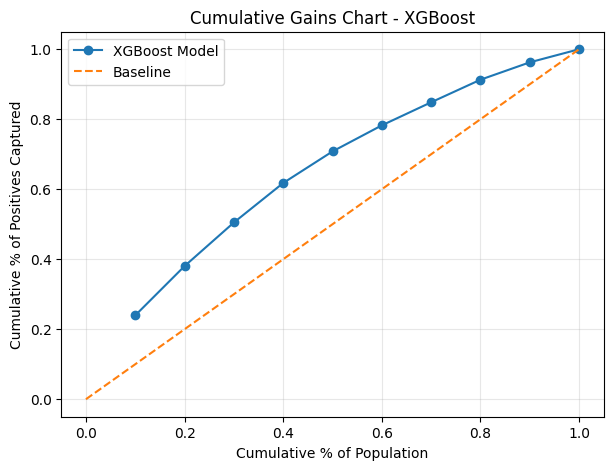

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    xgb_decile_summary["cum_population_pct"],
    xgb_decile_summary["cum_positive_pct"],
    marker="o",
    label="XGBoost Model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Baseline"
)

plt.xlabel("Cumulative % of Population")
plt.ylabel("Cumulative % of Positives Captured")
plt.title("Cumulative Gains Chart - XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Lift and Gains Comparison: LASSO vs XGBoost

### Key Findings

The baseline readmission rate in the dataset is approximately 11%. The models were evaluated by sorting patients according to predicted risk and dividing them into ten equal-sized deciles.

The XGBoost model demonstrates a **slightly stronger risk concentration in the highest-risk group**:

| Model | Top 10% Lift | Readmissions captured in top 20% |
|------|------|------|
LASSO Logistic Regression | 2.31 | 36.8% |
XGBoost | 2.40 | 38.0% |

This means that the top 10% of patients identified by the XGBoost model have a readmission rate approximately **2.4 times higher than the baseline**, indicating slightly better prioritization of high-risk cases.

Similarly, targeting the top 20% highest-risk patients identified by XGBoost captures **38% of all readmissions**, compared to **36.8% for the LASSO model**.

### Interpretation

While the improvement is modest, the XGBoost model consistently demonstrates better risk ranking performance across ROC-AUC, recall, and lift metrics.

This suggests that although much of the predictive signal in the dataset is captured by linear relationships, the gradient boosting model is able to exploit additional nonlinear patterns that slightly improve the prioritization of high-risk patients.

### Model Selection

Based on these results, the **tuned XGBoost model is selected as the final predictive model**, while the LASSO model remains an important interpretable benchmark.

# Threshold tuning the above XGBoost model that is tuned

## Threshold Tuning

Thresholds between 0.05 and 0.90 were evaluated in increments
of 0.01. At each threshold, precision, recall, and F1 were
computed against the training labels. The threshold maximizing
F1 was selected as the operating point — balancing the
precision-recall tradeoff without requiring explicit specification
of false positive and false negative costs.

The selected threshold was then applied to held-out test data
for final evaluation. The test set was not used at any stage
of threshold selection — preserving it as an honest estimate
of real-world performance.

In [132]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

# use final unscaled train set for XGBoost
X_train_xgb = X_train
y_train_array = y_train.values.ravel()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = cross_val_predict(
    best_xgb,
    X_train_xgb,
    y_train_array,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.arange(0.05, 0.91, 0.01)

xgb_threshold_results = []
for t in thresholds:
    y_pred_t = (oof_proba >= t).astype(int)
    xgb_threshold_results.append({
        "threshold": round(t, 2),
        "accuracy": accuracy_score(y_train_array, y_pred_t),
        "precision": precision_score(y_train_array, y_pred_t, zero_division=0),
        "recall": recall_score(y_train_array, y_pred_t, zero_division=0),
        "f1": f1_score(y_train_array, y_pred_t, zero_division=0)
    })

xgb_threshold_df = pd.DataFrame(xgb_threshold_results)

best_f1_row = xgb_threshold_df.loc[xgb_threshold_df["f1"].idxmax()]
optimal_threshold_xgb = best_f1_row["threshold"]

print(f"F1-optimal threshold: {optimal_threshold_xgb:.2f}")
display(best_f1_row.to_frame().T.round(4))

F1-optimal threshold: 0.55


,threshold,accuracy,precision,recall,f1
50,0.55,0.7329,0.2042,0.4608,0.283


In [133]:
from src.evaluate import compute_train_test_metrics

xgb_optimal_threshold_results = compute_train_test_metrics(
    model=best_xgb,
    X_train=X_train,
    y_train=y_train.values.ravel(),
    X_test=X_test_processed,
    y_test=y_test,
    threshold=optimal_threshold_xgb
)

display(xgb_optimal_threshold_results.round(4))

,Split,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Train,0.55,0.7419,0.2244,0.5115,0.3119,0.7094
1,Test,0.55,0.7334,0.1986,0.4553,0.2766,0.6675


In [127]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

X_train_xgb = X_train
y_train_array = y_train.values.ravel()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = cross_val_predict(
    best_xgb,
    X_train_xgb,
    y_train_array,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.arange(0.05, 0.91, 0.01)

xgb_threshold_df = []

for t in thresholds:
    y_pred_t = (oof_proba >= t).astype(int)
    xgb_threshold_df.append({
        "threshold": round(t, 2),
        "accuracy": accuracy_score(y_train_array, y_pred_t),
        "precision": precision_score(y_train_array, y_pred_t, zero_division=0),
        "recall": recall_score(y_train_array, y_pred_t, zero_division=0),
        "f1": f1_score(y_train_array, y_pred_t, zero_division=0)
    })

xgb_threshold_df = pd.DataFrame(xgb_threshold_df)

min_precision = 0.16
valid_rows = xgb_threshold_df[xgb_threshold_df["precision"] >= min_precision].copy()

best_recall_row = valid_rows.loc[valid_rows["recall"].idxmax()]
optimal_threshold_recall_xgb = best_recall_row["threshold"]

print(f"Recall-oriented threshold with precision >= {min_precision}: {optimal_threshold_recall_xgb:.2f}")
display(best_recall_row.to_frame().T.round(4))

Recall-oriented threshold with precision >= 0.16: 0.44


,threshold,accuracy,precision,recall,f1
39,0.44,0.5329,0.1602,0.7266,0.2625


In [129]:
from src.evaluate import compute_train_test_metrics

xgb_recall_threshold_results = compute_train_test_metrics(
    model=best_xgb,
    X_train=X_train,
    y_train=y_train.values.ravel(),
    X_test=X_test_processed,
    y_test=y_test,
    threshold=optimal_threshold_recall_xgb
)

display(xgb_recall_threshold_results.round(4))

,Split,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Train,0.44,0.5416,0.1691,0.7685,0.2772,0.7094
1,Test,0.44,0.5318,0.1561,0.7225,0.2567,0.6675


In [134]:
import pandas as pd
from src.evaluate import compute_train_test_metrics

# replace with your actual thresholds
xgb_default_threshold = 0.50
xgb_f1_threshold = optimal_threshold_xgb
xgb_recall_threshold = optimal_threshold_recall_xgb

xgb_default_df = compute_train_test_metrics(
    model=best_xgb,
    X_train=X_train,
    y_train=y_train.values.ravel(),
    X_test=X_test_processed,
    y_test=y_test,
    threshold=xgb_default_threshold
)
xgb_default_df["threshold_type"] = "Default 0.50"

xgb_f1_df = compute_train_test_metrics(
    model=best_xgb,
    X_train=X_train,
    y_train=y_train.values.ravel(),
    X_test=X_test_processed,
    y_test=y_test,
    threshold=xgb_f1_threshold
)
xgb_f1_df["threshold_type"] = "Best F1"

xgb_recall_df = compute_train_test_metrics(
    model=best_xgb,
    X_train=X_train,
    y_train=y_train.values.ravel(),
    X_test=X_test_processed,
    y_test=y_test,
    threshold=xgb_recall_threshold
)
xgb_recall_df["threshold_type"] = "Recall-Oriented"

xgb_threshold_comparison_df = pd.concat(
    [xgb_default_df, xgb_f1_df, xgb_recall_df],
    ignore_index=True
)

cols = ["threshold_type"] + [c for c in xgb_threshold_comparison_df.columns if c != "threshold_type"]
xgb_threshold_comparison_df = xgb_threshold_comparison_df[cols]

display(xgb_threshold_comparison_df.round(4))

,threshold_type,Split,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Default 0.50,Train,0.50,0.6531,0.1937,0.6429,0.2977,0.7094
1,Default 0.50,Test,0.50,0.6442,0.1761,0.5925,0.2715,0.6675
2,Best F1,Train,0.55,0.7419,0.2244,0.5115,0.3119,0.7094
3,Best F1,Test,0.55,0.7334,0.1986,0.4553,0.2766,0.6675
4,Recall-Oriented,Train,0.44,0.5416,0.1691,0.7685,0.2772,0.7094
5,Recall-Oriented,Test,0.44,0.5318,0.1561,0.7225,0.2567,0.6675


## Why does recall change dramatically while F1 and precision barely change?

During threshold tuning, we observed that increasing the classification threshold produced large changes in recall (sometimes ~15–20%) but only small changes in precision and F1 (often <2%). This behavior is expected for two main reasons: **class imbalance** and **moderate model separation**.

### 1. Class imbalance amplifies recall sensitivity

The dataset contains many more negative cases (no readmission) than positive cases (readmission). In such settings:

- **Recall** is defined as:

\[
Recall = TP / TP + FN
\]

Raising the classification threshold makes the model more conservative about predicting the positive class. As a result:

- True positives (TP) decrease
- False negatives (FN) increase

Because the denominator \(TP + FN\) equals the total number of positive cases, even small changes in TP can cause **large percentage changes in recall**.

### 2. Precision changes more slowly

Precision is defined as:

\[
Precision = TP/TP + FP
\]

When the threshold increases:

- TP decreases
- FP also decreases

Because both the numerator and denominator shrink together, precision tends to change more gradually. The reduction in false positives partially offsets the loss of true positives.

### 3. F1 score becomes relatively insensitive

The F1 score combines precision and recall:

\[
F1 = 2PR/P + R
\]

In this dataset, precision is relatively low (~0.17–0.20). When one component of the harmonic mean is much smaller than the other, the F1 score becomes dominated by the smaller value.

As a result:

- large changes in recall
- but small changes in precision

produce **only minor changes in F1**.

### 4. Moderate model separability

The model ROC AUC (~0.66–0.67) indicates moderate predictive power but not strong class separation. This means predicted probabilities for positive and negative cases overlap substantially.

Because of this overlap:

- moving the threshold mainly shifts the balance between TP and FN
- but does not dramatically improve the ratio of TP to FP

Thus, recall varies significantly while precision and F1 remain relatively stable.

### 5. Practical implication

Because the F1 curve is relatively flat across thresholds, threshold selection should be guided by the **business objective** rather than purely by metric optimization.

For example:

- Lower thresholds prioritize **higher recall** (capturing more potential readmissions)
- Higher thresholds prioritize **higher precision and operational efficiency**

In risk-screening applications, recall is often more important because missing a truly high-risk case may be more costly than investigating an additional false positive.

# XGBoost Built-in-Feature Importance

any_prior_inpatient                     0.167770
discharge_disposition_Home              0.081323
institutional_discharge                 0.077636
prior_utilization_score                 0.046356
discharge_disposition_Rehab             0.027989
number_diagnoses                        0.015008
diag_1_category_Musculoskeletal         0.013445
discharge_disposition_Transfer          0.012656
discharge_disposition_Long_Term_Care    0.012586
any_prior_emergency                     0.012112
medical_specialty_group_Other           0.011801
diabetesMed                             0.011715
diag_2_category_Neoplasms               0.011527
diag_1_category_Respiratory             0.011337
insulin_flag                            0.011147
age_ordinal                             0.011133
diag_1_category_Other                   0.011040
discharge_disposition_Home_Health       0.010821
time_in_hospital                        0.010598
diabetes_primary_diag                   0.009910
dtype: float32

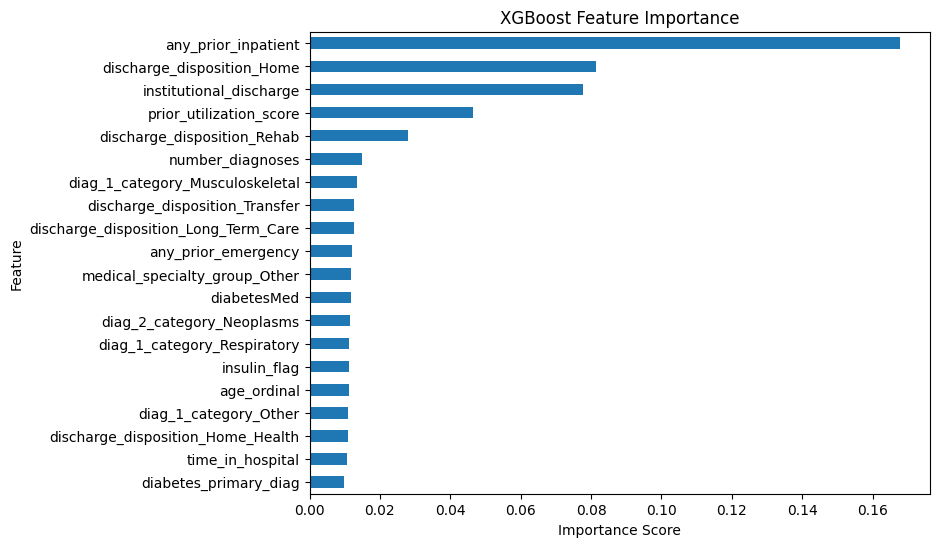

In [136]:
# get importance scores
xgb_importance = pd.Series(
    best_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# view top features
display(xgb_importance.head(20))

# plot
plt.figure(figsize=(8,6))
xgb_importance.head(20).sort_values().plot.barh()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

## Permutation Importance

prior_utilization_score            0.030649
any_prior_inpatient                0.014801
discharge_disposition_Home         0.009307
institutional_discharge            0.009181
discharge_disposition_Rehab        0.005226
number_diagnoses                   0.003191
diag_1_category_Respiratory        0.002616
age_ordinal                        0.002405
n_active_diabetes_meds             0.002093
discharge_disposition_Transfer     0.001788
diag_1_category_Other              0.001624
diabetesMed                        0.001615
num_medications                    0.001588
diag_2_category_Neoplasms          0.001399
time_in_hospital                   0.001392
diag_1_category_Musculoskeletal    0.000993
diag_2_category_Diabetes           0.000601
admission_source_Transfer          0.000570
med_intensity                      0.000553
diag_3_category_Genitourinary      0.000489
dtype: float64

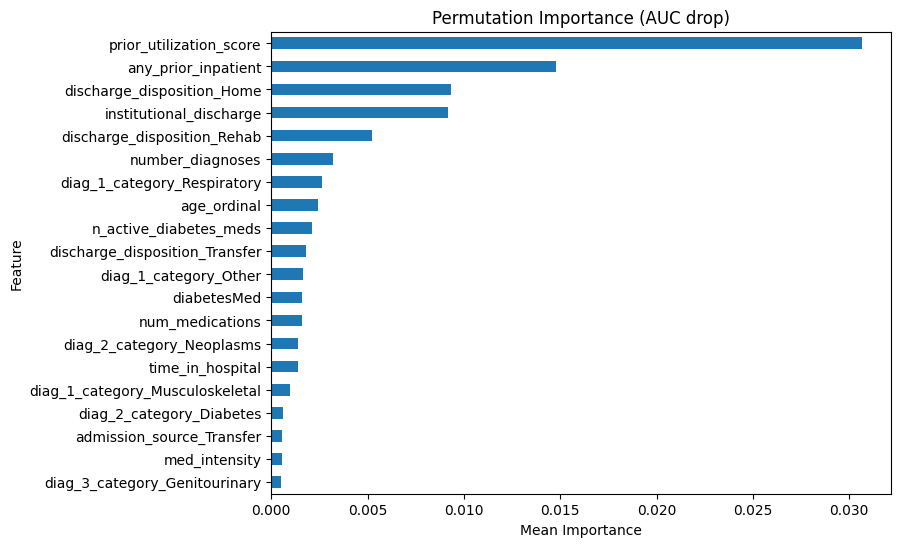

In [137]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_xgb,
    X_test_processed,
    y_test,
    n_repeats=20,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.Series(
    perm_importance.importances_mean,
    index=X_test_processed.columns
).sort_values(ascending=False)

display(perm_importance_df.head(20))

plt.figure(figsize=(8,6))
perm_importance_df.head(20).sort_values().plot.barh()
plt.title("Permutation Importance (AUC drop)")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.show()

## From both these analysis we can see that 4 features are important - 

1️⃣ prior_utilization_score - past utilization is one of the strongest predictors of future hospitalization
2️⃣ any_prior_inpatient - Patients recently admitted to hospital have ongoing or complex conditions, increasing readmission risk.
3️⃣ discharge_disposition variables - discharge_dispostiion_Home, instituitonal_discharge, discharge_disposition_Rehab represent patients discharged to rehabilitation facilities or institutions often have higher severity illness or functional limitations
4️⃣ number_diagnoses - these measure clinical burden 

## Feature experiment 

Based on the results from the above two analysis, we will shortlist the top X features and remove any that do not contribute to the predictive power of the model. We will rely on permuation importance because essentially built in XGBOOST importance measures how often a feature was used for splits and how much it reduced impurity. Biased toward high cardinality features. Doesn't tell you what happens to predictions if you remove the feature. But Permutation importance directly tells you how the performance drops if a feature is removed

### Identify features with low predictive power

In [139]:
low_importance_features = perm_importance_df[
    perm_importance_df <= 0
].index.tolist()

print("Features with no predictive contribution:")
print(len(low_importance_features))
print(low_importance_features)

Features with no predictive contribution:
15
['discharge_disposition_Long_Term_Care', 'discharge_disposition_Unknown', 'admission_source_Other', 'admission_type_Other', 'race_Asian', 'medical_specialty_group_Specialty_Medicine', 'medical_specialty_group_Radiology', 'diag_2_category_Musculoskeletal', 'admission_type_Unknown', 'diag_2_category_Injury', 'medical_specialty_group_Surgery', 'change', 'medical_specialty_group_Nephrology', 'gender', 'A1Cresult_>8']


Many of the variables suggested are part of a one hot encoded dummy variable. It is not fair to remove just one of these dummy encoded variables as sometimes permutation importance can underestimate individual dummy variables because shuffling one dummy while leaving others intact may not fully break the feature's signal. The model routes predictions through correlated dummies.permutation importance on individual dummies can be misleading. Nephrology might look unimportant individually but contribute as part of the medical_specialty_group feature family. For a better understanding of the variables, we will move on to SHAP analysis

# SHAP ANALYSIS

In [145]:
import shap
import numpy as np
import pandas as pd

X_shap = X_test_processed.copy()

explainer = shap.TreeExplainer(best_xgb)
shap_explanation = explainer(X_shap)

shap_values = shap_explanation.values

In [144]:
feature_groups = {
    'race': [c for c in X_shap.columns if c.startswith('race_')],
    'admission_type': [c for c in X_shap.columns if c.startswith('admission_type_')],
    'discharge_disposition': [c for c in X_shap.columns if c.startswith('discharge_disposition_')],
    'diag_1_category': [c for c in X_shap.columns if c.stabrtswith('diag_1_category_')],
    'diag_2_category': [c for c in X_shap.columns if c.startswith('diag_2_category_')],
    'diag_3_category': [c for c in X_shap.columns if c.startswith('diag_3_category_')],
    'medical_specialty_group': [c for c in X_shap.columns if c.startswith('medical_specialty_group_')],
    'admission_source': [c for c in X_shap.columns if c.startswith('admission_source_')],
    'A1Cresult': [c for c in X_shap.columns if c.startswith('A1Cresult_')],
}

already_grouped = [c for cols in feature_groups.values() for c in cols]
for col in X_shap.columns:
    if col not in already_grouped:
        feature_groups[col] = [col]

grouped_importance = {}
for group_name, cols in feature_groups.items():
    col_indices = [X_shap.columns.get_loc(c) for c in cols if c in X_shap.columns]
    if len(col_indices) > 0:
        grouped_importance[group_name] = np.abs(
            shap_values[:, col_indices]
        ).sum(axis=1).mean()

grouped_df = pd.DataFrame({
    'feature_group': list(grouped_importance.keys()),
    'total_shap_importance': list(grouped_importance.values())
}).sort_values('total_shap_importance', ascending=False)

print("Grouped feature importance:")
display(grouped_df.round(4))

Grouped feature importance:


,feature_group,total_shap_importance
27,prior_utilization_score,0.1899
2,discharge_disposition,0.1808
24,any_prior_inpatient,0.1772
30,institutional_discharge,0.0933
3,diag_1_category,0.0775
6,medical_specialty_group,0.0664
17,age_ordinal,0.0614
14,number_diagnoses,0.0527
4,diag_2_category,0.0514
13,num_medications,0.0384


Clinically Grouped Feature Importance:


,feature_group,total_shap_importance,pct_of_total
0,prior_utilization,0.3874,28.1
1,discharge_disposition,0.2741,19.9
2,encounter_intensity,0.2187,15.9
3,diagnosis,0.1736,12.6
4,medication_management,0.1195,8.7
5,demographics,0.0832,6.0
6,medical_specialty,0.0664,4.8
7,admission_context,0.0283,2.1
8,lab_results,0.0269,2.0


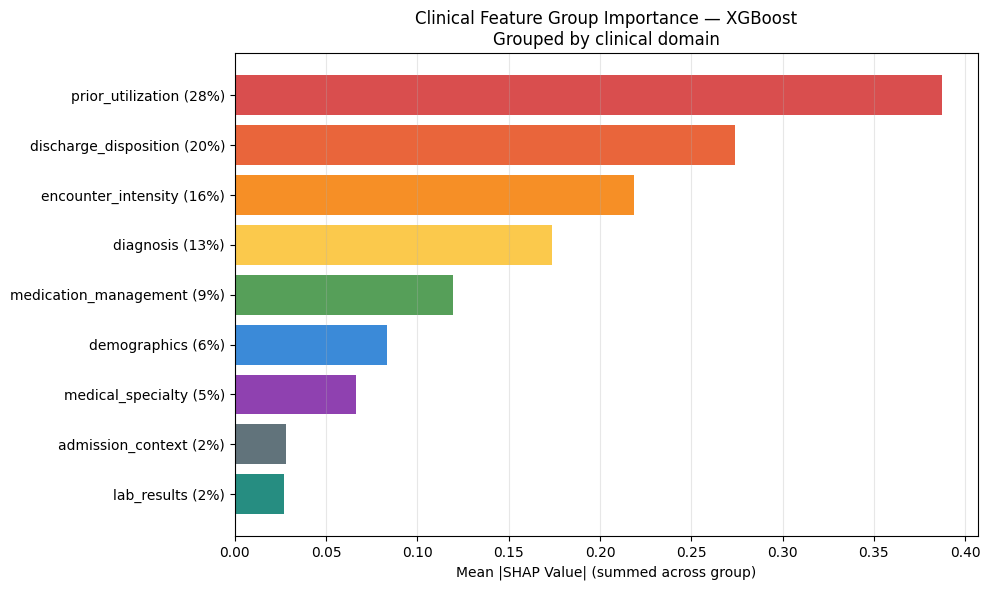

In [216]:
feature_groups_clinical = {
    # Prior utilization — all measures of healthcare history
    'prior_utilization': [
        'prior_utilization_score',
        'any_prior_inpatient',
        'any_prior_emergency',
        'any_prior_outpatient',
        
    ],
    
    # Discharge context
    'discharge_disposition': [
        c for c in X_shap.columns 
        if c.startswith('discharge_disposition_')
    ] + ['institutional_discharge'],
    
    # Diagnosis features
    'diagnosis': [
        c for c in X_shap.columns 
        if c.startswith('diag_1_category_')
        or c.startswith('diag_2_category_')
        or c.startswith('diag_3_category_')
    ] + ['diabetes_primary_diag'],
    
    # Medical specialty
    'medical_specialty': [
        c for c in X_shap.columns 
        if c.startswith('medical_specialty_group_')
    ],
    
    # Medication management
    'medication_management': [
        'diabetesMed',
        'n_active_diabetes_meds',
        'n_med_decreases',
        'n_med_increases',
        'insulin_flag',
        'insulin_change',
        'change',
    ],
    
    # Encounter intensity — current admission
    'encounter_intensity': [
        'num_medications',
        'num_lab_procedures',
        'num_procedures',
        'time_in_hospital',
        'lab_intensity',
        'med_intensity',
        'number_diagnoses',
    ],
    
    # Patient demographics
    'demographics': [
        c for c in X_shap.columns if c.startswith('race_')
    ] + ['age_ordinal', 'gender'],
    
    # Admission context
    'admission_context': [
        c for c in X_shap.columns 
        if c.startswith('admission_type_')
        or c.startswith('admission_source_')
    ],
    
    # Lab results
    'lab_results': [
        c for c in X_shap.columns if c.startswith('A1Cresult_')
    ],
}

# Calculate grouped importance
grouped_clinical = {}
for group_name, cols in feature_groups_clinical.items():
    col_indices = [
        X_shap.columns.get_loc(c) 
        for c in cols if c in X_shap.columns
    ]
    if col_indices:
        grouped_clinical[group_name] = float(
            np.abs(shap_values[:, col_indices]).sum(axis=1).mean()
        )

grouped_clinical_df = (
    pd.DataFrame({
        'feature_group': list(grouped_clinical.keys()),
        'total_shap_importance': list(grouped_clinical.values())
    })
    .sort_values('total_shap_importance', ascending=False)
    .reset_index(drop=True)
)

grouped_clinical_df['pct_of_total'] = (
    grouped_clinical_df['total_shap_importance'] / 
    grouped_clinical_df['total_shap_importance'].sum() * 100
).round(1)

print("Clinically Grouped Feature Importance:")
display(grouped_clinical_df.round(4))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d32f2f', '#e64a19', '#f57c00', '#fbc02d', 
          '#388e3c', '#1976d2', '#7b1fa2', '#455a64', '#00796b']

bars = ax.barh(
    range(len(grouped_clinical_df)),
    grouped_clinical_df['total_shap_importance'],
    color=colors[:len(grouped_clinical_df)],
    alpha=0.85
)

ax.set_yticks(range(len(grouped_clinical_df)))
ax.set_yticklabels([
    f"{row['feature_group']} ({row['pct_of_total']:.0f}%)"
    for _, row in grouped_clinical_df.iterrows()
])
ax.set_xlabel('Mean |SHAP Value| (summed across group)')
ax.set_title(
    'Clinical Feature Group Importance — XGBoost\n'
    'Grouped by clinical domain',
    fontsize=12
)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()

plt.savefig(f"{OUTPUTS_DIR}/figures/shap_grouped.png", dpi=150, bbox_inches='tight')
plt.show()

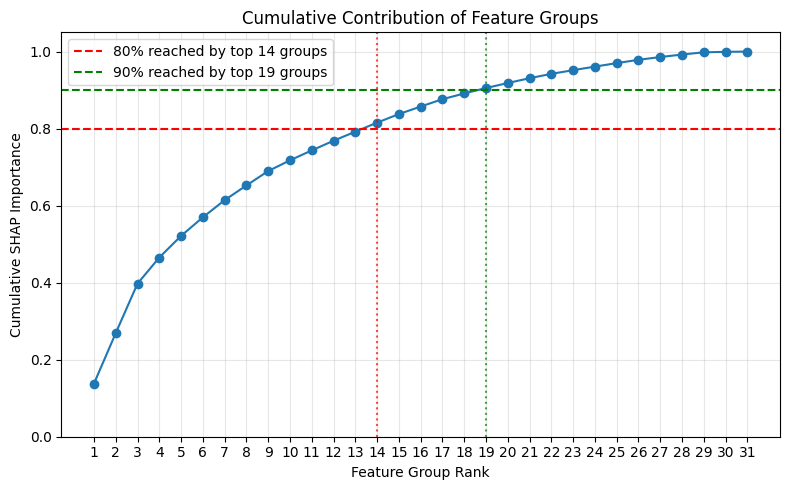

Top groups contributing to 80% importance:


,rank,feature_group,total_shap_importance,cumulative_pct
0,1,prior_utilization_score,0.1899,0.1378
1,2,discharge_disposition,0.1808,0.2689
2,3,any_prior_inpatient,0.1772,0.3975
3,4,institutional_discharge,0.0933,0.4652
4,5,diag_1_category,0.0775,0.5215
5,6,medical_specialty_group,0.0664,0.5697
6,7,age_ordinal,0.0614,0.6142
7,8,number_diagnoses,0.0527,0.6524
8,9,diag_2_category,0.0514,0.6898
9,10,num_medications,0.0384,0.7176


Top groups contributing to 90% importance:


,rank,feature_group,total_shap_importance,cumulative_pct
0,1,prior_utilization_score,0.1899,0.1378
1,2,discharge_disposition,0.1808,0.2689
2,3,any_prior_inpatient,0.1772,0.3975
3,4,institutional_discharge,0.0933,0.4652
4,5,diag_1_category,0.0775,0.5215
5,6,medical_specialty_group,0.0664,0.5697
6,7,age_ordinal,0.0614,0.6142
7,8,number_diagnoses,0.0527,0.6524
8,9,diag_2_category,0.0514,0.6898
9,10,num_medications,0.0384,0.7176


In [154]:
shap_df = grouped_df.copy().reset_index(drop=True)
shap_df["cumulative_importance"] = shap_df["total_shap_importance"].cumsum()
shap_df["cumulative_pct"] = shap_df["cumulative_importance"] / shap_df["total_shap_importance"].sum()
shap_df["rank"] = np.arange(1, len(shap_df) + 1)

# find cutoff ranks
rank_80 = shap_df.loc[shap_df["cumulative_pct"] >= 0.80, "rank"].iloc[0]
rank_90 = shap_df.loc[shap_df["cumulative_pct"] >= 0.90, "rank"].iloc[0]

plt.figure(figsize=(8,5))

plt.plot(
    shap_df["rank"],
    shap_df["cumulative_pct"],
    marker="o"
)

plt.axhline(0.80, linestyle="--", color="red", label=f"80% reached by top {rank_80} groups")
plt.axhline(0.90, linestyle="--", color="green", label=f"90% reached by top {rank_90} groups")
plt.axvline(rank_80, linestyle=":", color="red", alpha=0.7)
plt.axvline(rank_90, linestyle=":", color="green", alpha=0.7)

plt.xlabel("Feature Group Rank")
plt.ylabel("Cumulative SHAP Importance")
plt.title("Cumulative Contribution of Feature Groups")
plt.xticks(shap_df["rank"])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Top groups contributing to 80% importance:")
display(shap_df.loc[:rank_80-1, ["rank", "feature_group", "total_shap_importance", "cumulative_pct"]].round(4))

print("Top groups contributing to 90% importance:")
display(shap_df.loc[:rank_90-1, ["rank", "feature_group", "total_shap_importance", "cumulative_pct"]].round(4))

### Grouped SHAP Feature Importance

Individual SHAP values for one-hot encoded dummy variables
underrepresent categorical feature contribution by distributing
importance across multiple columns. Features are grouped by
clinical domain — summing SHAP contributions across all
dummies belonging to the same original feature.

**The top four clinical feature groups account for 77% of
total predictive signal:**

**Prior Utilization (28%)** — the dominant predictor group.
A patient's history of inpatient admissions, emergency visits,
and outpatient contacts is the strongest signal available in
administrative data. Patients who have been hospitalized
before are most likely to be hospitalized again — a finding
consistent with clinical literature on readmission risk.
The engineered prior_utilization_score — a weighted
combination of inpatient, emergency, and outpatient history —
is the single most important individual feature.

**Discharge Disposition (20%)** — where a patient goes
after discharge reflects clinical stability and directly
predicts readmission risk. Rehabilitation and transfer
discharges carry substantially higher risk than home
discharge, consistent with Lasso regression coefficients
(Rehab: +0.906, Home: -0.379). This feature group validates
the clinical judgment embedded in discharge planning.

**Encounter Intensity (16%)** — how complex was this
admission? Number of diagnoses, medications, lab procedures,
and length of stay collectively capture disease burden during
the current encounter. More intensive encounters indicate
sicker patients with higher readmission risk.

**Diagnosis (13%)** — primary and secondary diagnosis
categories contribute meaningful signal, particularly
diabetes and circulatory diagnoses consistent with the
dataset's focus on diabetic patients with high rates of
cardiovascular comorbidity.

**Lower-importance groups:**

Medication management (9%), demographics (6%), and
medical specialty (5%) contribute meaningful but secondary
signal. Admission context (2%) and lab results (2%) add
minimal predictive value — lab results limited by 83%
A1Cresult missingness, admission context largely captured
by discharge disposition and utilization features.

**Race contributes minimally** (part of 6% demographics
group, primarily driven by age_ordinal) — consistent with
the near-zero Cramér's V (0.017) found during feature
analysis. Race is retained for fairness analysis rather
than predictive contribution.

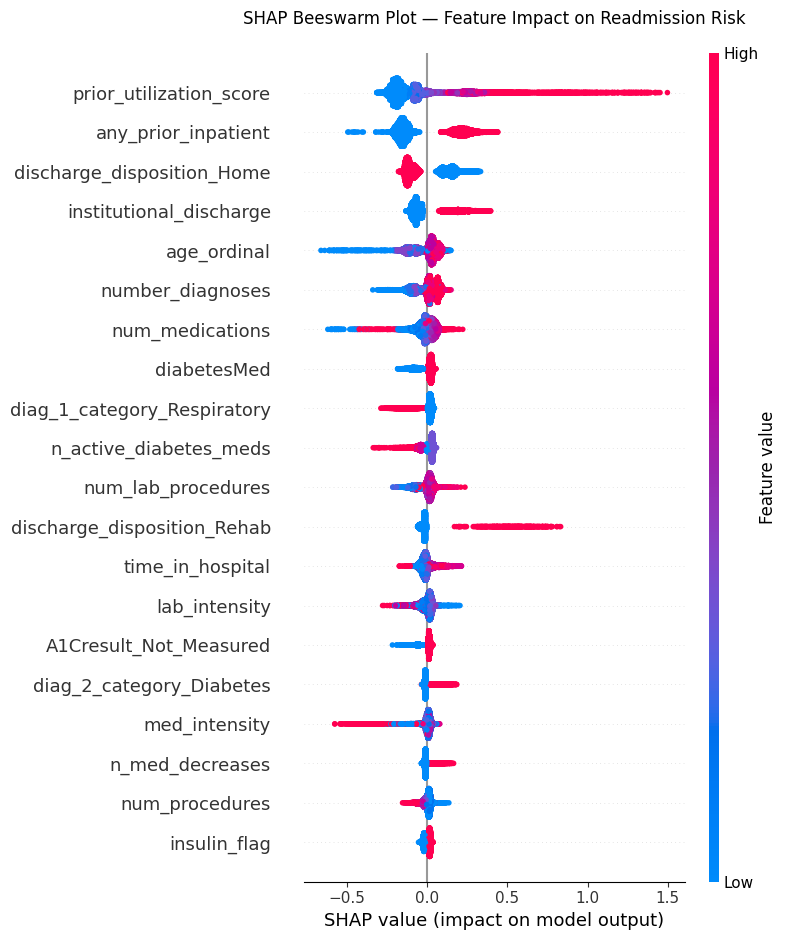

In [217]:
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values,
    X_test_processed,
    max_display=20,
    show=False
)
plt.title(
    'SHAP Beeswarm Plot — Feature Impact on Readmission Risk\n'
    #'Red = high feature value, Blue = low feature value'
    ,
    fontsize=12
)
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/figures/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

## SHAP Beeswarm Plot

### Purpose

The beeswarm plot provides a unified view of feature importance,
direction, and distribution across all test observations
simultaneously — answering three questions at once:

- **Which features matter most?** Features at the top have
  the widest spread of SHAP values — larger average impact
  on predictions
- **Which direction does each feature push predictions?**
  Points to the right increase readmission risk. Points to
  the left decrease it.
- **Is the effect consistent or variable across patients?**
  Tight clusters indicate consistent effects. Wide spread
  indicates the feature has large impact for some patients
  and minimal impact for others.

Each point represents one patient. Color indicates the
feature value for that patient — red for high values,
blue for low values. The x-axis shows the SHAP value —
the feature's contribution to that patient's risk score
relative to the population average.

The top 20 features are displayed, ranked by mean absolute
SHAP value. These 20 features account for the majority of
total predictive signal in the model.

---

### Key Observations

**prior_utilization_score** shows the widest range of any
feature — red dots (high prior utilization) extend far
right with SHAP values up to +1.5. Patients with extensive
hospitalization history receive dramatically elevated risk
scores. The long tail identifies the highest-confidence
intervention targets in the population.

**any_prior_inpatient** shows a clean binary split — patients
with any prior inpatient admission (red) score higher than
those without (blue). Having been hospitalized before is a
reliable readmission risk signal independent of utilization
volume.

**discharge_disposition_Home** shows a protective effect —
patients discharged home (red, value=1) receive negative
SHAP values, reducing their risk score. Patients not
discharged home (blue, value=0) receive positive SHAP
values. Being sent home reflects clinical stability.

**discharge_disposition_Rehab** demonstrates a striking
pattern — patients discharged to rehabilitation facilities
receive large positive SHAP values up to +0.9, making it
one of the strongest individual risk signals. Consistent
with the highest Lasso coefficient in the linear model
(+0.906).

**diag_1_category_Respiratory** shows a counterintuitive
negative effect — respiratory primary diagnosis reduces
readmission risk. This reflects that respiratory admissions
are often acute and treatable, with patients recovering
fully rather than cycling back through the hospital.

**age_ordinal and num_medications** show mixed color
patterns — indicating non-linear effects that XGBoost
captures through tree interactions. These nuanced
relationships are unavailable to logistic regression,
partially explaining why XGBoost achieves higher recall
at comparable AUC.

---

### Directional Validation

Of the top 20 features displayed, the direction of effect
is consistent with clinical expectations for the majority
of features

Features showing counterintuitive directions —
diag_1_category_Respiratory and n_active_diabetes_meds —
have defensible clinical explanations rather than reflecting
model errors. Respiratory admissions tend to be acute and
recoverable. Higher active medication counts may reflect
well-managed chronic disease in patients receiving
comprehensive pharmaceutical care.

Patient index: 211
Predicted probability: 0.678
Actual outcome: Readmitted ✓

Top features driving this prediction:
                                 feature  shap_value feature_value
18               prior_utilization_score      0.1525             6
15                   any_prior_inpatient      0.1471             1
21               institutional_discharge      0.1206             1
37            discharge_disposition_Home      0.0854         False
1                       time_in_hospital      0.0698             8
5                       number_diagnoses      0.0387             8
50  medical_specialty_group_Primary_Care      0.0377          True
8                            age_ordinal      0.0359             7
10                n_active_diabetes_meds      0.0306             1
41           discharge_disposition_Rehab     -0.0226         False
2                     num_lab_procedures      0.0220            53
12                       n_med_decreases     -0.0199             0
17           

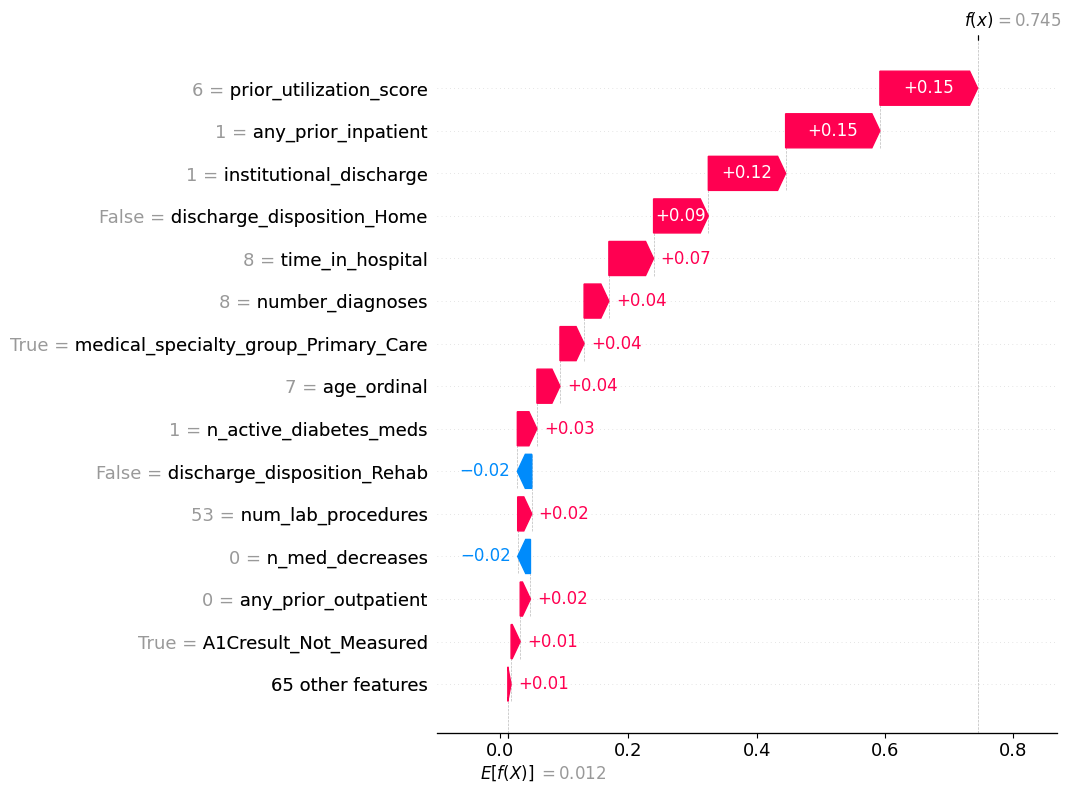

In [222]:
y_prob_test = best_xgb.predict_proba(X_test_processed)[:, 1]
y_test_array = np.array(y_test)

# Find high risk patient who was actually readmitted
true_positive_mask = (y_prob_test > 0.6) & (y_test_array == 1)
tp_indices = np.where(true_positive_mask)[0]

if len(tp_indices) > 0:
    idx = tp_indices[0]
else:
    idx = np.argmax(y_prob_test)

print(f"Patient index: {idx}")
print(f"Predicted probability: {y_prob_test[idx]:.3f}")
print(f"Actual outcome: {'Readmitted ✓' if y_test_array[idx] == 1 else 'Not Readmitted'}")
print(f"\nTop features driving this prediction:")

# Show top contributing features for this patient
patient_shap = pd.DataFrame({
    'feature': X_test_processed.columns,
    'shap_value': shap_values[idx],
    'feature_value': X_test_processed.iloc[idx].values
}).sort_values('shap_value', key=abs, ascending=False).head(20)
print(patient_shap.round(4))

plt.figure(figsize=(10,6))

# Waterfall plot
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_processed.iloc[idx].values,
        feature_names=X_test_processed.columns.tolist()
    ),
    max_display=15,
    show=False
)

plt.savefig(f"{OUTPUTS_DIR}/figures/shap_waterfall.png",
            dpi=150,
            bbox_inches='tight')

plt.show()

## SHAP Waterfall Plot — Individual Patient Explanation

### Purpose

The waterfall plot explains why a specific patient received
their readmission risk score, decomposing the prediction
into individual feature contributions. This is the
interpretability capability required for clinical deployment:
a clinician can examine exactly which factors drove the
model's assessment and validate whether the reasoning
is clinically sound.

### Patient Profile — High Risk True Positive

**Predicted readmission probability: 0.678**
**Actual outcome: Readmitted within 30 days ✓**
**Baseline population average: 0.11**

The model correctly identified this patient as high risk 
pushing their score from the 0.11 population baseline to
0.678 through the cumulative effect of multiple risk factors.

---

### Risk Factor Decomposition

**Primary risk drivers (pushing score upward):**

- **Prior utilization score = 6** (+0.153) — the single
  largest contributor. This patient has a significant
  history of prior hospitalizations and emergency visits,
  establishing the strongest available signal for
  readmission risk.

- **Any prior inpatient = Yes** (+0.147) — confirms prior
  hospitalization history independently of the utilization
  score. Having been admitted before is a reliable
  readmission predictor.

- **Institutional discharge** (+0.121) — the patient is
  not being discharged home, indicating insufficient
  clinical stability for independent recovery.

- **Time in hospital = 8 days** (+0.070) — a lengthy
  admission reflecting admission complexity and disease
  severity beyond what diagnosis codes alone capture.

- **Number of diagnoses = 8** (+0.039) — high comorbidity
  burden. Managing 8 concurrent conditions increases
  post-discharge deterioration risk.

- **Age = 70s** (+0.036) — older age compounds all other
  risk factors.

**Risk-reducing features (pushing score downward):**

- **Not discharged to Rehab** (-0.023) — absence of rehab
  discharge slightly reduces risk relative to that high-risk
  category
- **No medication decreases** (-0.020) — stable medication
  regimen without de-escalation

---

### Clinical Interpretation

This patient presents a clinically coherent high-risk profile:
an elderly patient with extensive prior hospitalization
history, multiple comorbidities, a lengthy current admission,
and a discharge destination other than home. Each factor
independently elevates readmission risk,  their combination
produces a well-justified high risk score.

The model's reasoning is transparent and clinically
defensible. A care coordinator reviewing this explanation
would immediately recognize the risk profile and understand
why targeted post-discharge intervention is warranted.

In [225]:
[c for c in X_test_processed.columns 
     if c.startswith('admission_type_') 
     or c.startswith('admission_source_')] + [c for c in X_test_processed.columns 
       if c.startswith('A1Cresult_')]

['admission_type_Emergency',
 'admission_type_Other',
 'admission_type_Unknown',
 'admission_type_Urgent',
 'admission_source_Other',
 'admission_source_Physician_Referral',
 'admission_source_Transfer',
 'A1Cresult_>8',
 'A1Cresult_Norm',
 'A1Cresult_Not_Measured']

In [ ]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

from src.evaluate import compute_train_test_metrics

# Features to remove — entire low-importance groups
cols_to_remove = (
    [c for c in X_test_processed.columns 
     if c.startswith('admission_type_') 
     or c.startswith('admission_source_')] + [c for c in X_test_processed.columns 
       if c.startswith('A1Cresult_')]
)


print("Columns being dropped:")
print(cols_to_remove)
print("Number dropped:", len(cols_to_remove))

X_train_reduced = X_train.drop(columns=cols_to_remove).copy()
X_test_reduced = X_test_processed.drop(columns=cols_to_remove).copy()

print("Full shape:", X_train.shape, X_test_processed.shape)
print("Reduced shape:", X_train_reduced.shape, X_test_reduced.shape)

# ------------------------------------------------------------------
# 2. Recreate reduced model using SAME tuned params as best_xgb
# ------------------------------------------------------------------
xgb_reduced = XGBClassifier(**best_xgb.get_params())

# Fit reduced model on reduced training data
xgb_reduced.fit(X_train_reduced, y_train.values.ravel())

# ------------------------------------------------------------------
# 3. OOF predictions for reduced model threshold tuning
# ------------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_train_array = y_train.values.ravel()

oof_proba_reduced = cross_val_predict(
    xgb_reduced,
    X_train_reduced,
    y_train_array,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("OOF predictions shape:", oof_proba_reduced.shape)

# ------------------------------------------------------------------
# 4. Recall-oriented threshold for reduced model
#    highest recall subject to precision >= 0.16
# ------------------------------------------------------------------
thresholds = np.arange(0.05, 0.91, 0.01)

results_reduced = []
for t in thresholds:
    y_pred_t = (oof_proba_reduced >= t).astype(int)
    p = precision_score(y_train_array, y_pred_t, zero_division=0)
    r = recall_score(y_train_array, y_pred_t, zero_division=0)
    f = f1_score(y_train_array, y_pred_t, zero_division=0)

    results_reduced.append({
        "threshold": round(t, 2),
        "precision": p,
        "recall": r,
        "f1": f
    })

results_reduced_df = pd.DataFrame(results_reduced)

valid = results_reduced_df[results_reduced_df["precision"] >= 0.16].copy()
best_reduced = valid.loc[valid["recall"].idxmax()]
optimal_threshold_reduced = float(best_reduced["threshold"])

print(f"Full model threshold:    {optimal_threshold_recall_xgb:.2f}")
print(f"Reduced model threshold: {optimal_threshold_reduced:.2f}")
print("\nReduced model OOF metrics at chosen threshold:")
display(best_reduced.to_frame().T.round(4))

# ------------------------------------------------------------------
# 5. Evaluate full vs reduced using their chosen thresholds
# ------------------------------------------------------------------
print("\nFull model:")
xgb_full_results = compute_train_test_metrics(
    model=best_xgb,
    X_train=X_train,
    y_train=y_train_array,
    X_test=X_test_processed,
    y_test=y_test,
    threshold=optimal_threshold_recall_xgb
)
display(xgb_full_results.round(4))

print(f"\nReduced model ({X_train_reduced.shape[1]} features):")
xgb_reduced_results = compute_train_test_metrics(
    model=xgb_reduced,
    X_train=X_train_reduced,
    y_train=y_train_array,
    X_test=X_test_reduced,
    y_test=y_test,
    threshold=optimal_threshold_reduced
)
display(xgb_reduced_results.round(4))

# ------------------------------------------------------------------
# 6. Threshold-independent AUC comparison
# ------------------------------------------------------------------
full_auc = roc_auc_score(
    y_test,
    best_xgb.predict_proba(X_test_processed)[:, 1]
)

reduced_auc = roc_auc_score(
    y_test,
    xgb_reduced.predict_proba(X_test_reduced)[:, 1]
)

print("\nAUC Comparison (threshold-independent):")
print(f"Full model    — {X_train.shape[1]} features: {full_auc:.4f}")
print(f"Reduced model — {X_train_reduced.shape[1]} features: {reduced_auc:.4f}")
print(f"AUC change: {reduced_auc - full_auc:+.4f}")

Columns being dropped:
['number_emergency', 'number_inpatient', 'number_outpatient']
Number dropped: 3
Full shape: (79538, 79) (19802, 79)
Reduced shape: (79538, 69) (19802, 69)
OOF predictions shape: (79538,)
Full model threshold:    0.44
Reduced model threshold: 0.45

Reduced model OOF metrics at chosen threshold:


,threshold,precision,recall,f1
40,0.45,0.162,0.701,0.2632



Full model:


,Split,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Train,0.44,0.5416,0.1691,0.7685,0.2772,0.7094
1,Test,0.44,0.5318,0.1561,0.7225,0.2567,0.6675



Reduced model (69 features):


,Split,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Train,0.45,0.5559,0.1714,0.7519,0.2792,0.7070
1,Test,0.45,0.5492,0.1598,0.7112,0.2609,0.6673



AUC Comparison (threshold-independent):
Full model    — 79 features: 0.6675
Reduced model — 69 features: 0.6673
AUC change: -0.0002


### Feature Reduction Experiment

**Hypothesis:** The two lowest-importance feature groups —
admission context (2% of total SHAP importance) and lab
results (2%) — contribute negligible predictive signal
and can be removed without meaningful performance loss.

**Method:** XGBoost retrained on 69 features (removing
10 columns from admission_type, admission_source, and
A1Cresult groups). Threshold re-tuned using identical
cross-validated OOF methodology for fair comparison.

**Results:**

| Model | Features | Test AUC | Test Recall | Test Precision |
|---|---|---|---|---|
| Full model | 79 | 0.6675 | 72.25% | 15.61% |
| Reduced model | 69 | 0.6673 | 71.12% | 15.98% |
| **Change** | **-10** | **-0.0002** | **-1.13%** | **+0.37%** |

**Conclusion:** Removing 10 features representing the two
lowest-importance clinical groups produces an AUC reduction
of 0.0002 — statistically and operationally negligible.
Recall decreases by 1.1 percentage points while precision
improves marginally.

This confirms the SHAP grouped importance ranking —
admission context and lab results contribute approximately
2% each of total predictive signal. Their removal does
not meaningfully impair model performance.

**Deployment decision:** The full 79-feature model is
retained as the production model. The marginal computational
cost of 10 additional features at scoring time is negligible,
while retaining them preserves the complete clinical
information set and avoids the risk of inadvertently
removing signal for specific patient subgroups.

If computational constraints required feature reduction —
for example in a low-latency mobile clinical application —
the 69-feature model provides equivalent performance with
a simpler feature set.

## ROC curve for final XGB reduced model selected

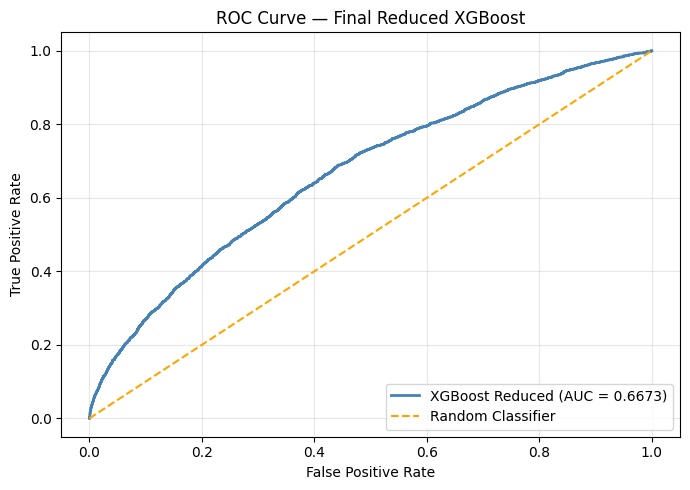

In [226]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_reduced = xgb_reduced.predict_proba(X_test_reduced)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_reduced)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'XGBoost Reduced (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='orange', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final Reduced XGBoost')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/figures/roc_curve_xgb_reduced.png", dpi=150, bbox_inches='tight')
plt.show()

# Calibration plot

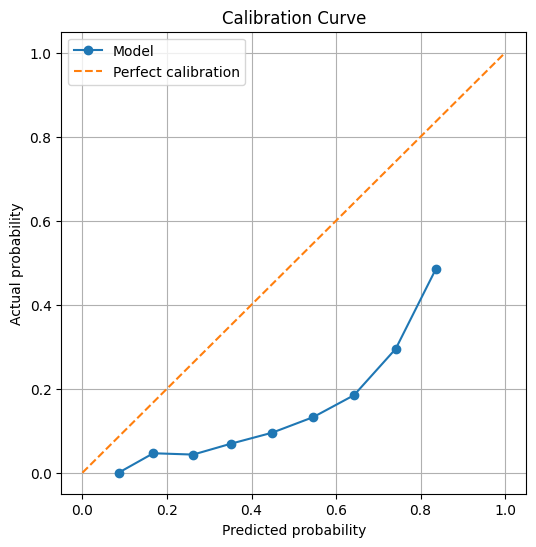

In [218]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

y_prob = xgb_reduced.predict_proba(X_test_reduced)[:, 1]

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0,1], [0,1], linestyle='--', label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Actual probability")
plt.title("Calibration Curve")
plt.legend()
plt.grid()
plt.savefig(f"{OUTPUTS_DIR}/figures/calibration.png", dpi=150, bbox_inches='tight')
plt.show()

### Calibration Analysis

To evaluate how well predicted probabilities align with
actual outcomes, a calibration curve was plotted comparing
predicted readmission probabilities with observed
readmission rates across score bins.

The model's predicted probabilities consistently exceed
actual readmission rates — the calibration curve falls
below the diagonal throughout, indicating systematic
overestimation of readmission risk. For example, patients
predicted to have an 80% probability of readmission
exhibit an actual readmission rate closer to 45%.

This miscalibration is expected for two reasons. First,
cost-sensitive training (scale_pos_weight) inflates
probability scores for the minority class to improve
recall — a deliberate tradeoff that improves detection
at the cost of probability accuracy. Second, tree-based
models such as XGBoost optimize ranking performance
(AUC) rather than probability accuracy, making some
degree of miscalibration typical.

Despite this, the model remains effective for risk
ranking and patient prioritization — the primary clinical
objective. Higher predicted scores genuinely correspond
to higher readmission risk, enabling targeted
post-discharge interventions even when absolute
probability values are inflated.

Predicted probabilities should not be interpreted as
exact readmission likelihoods without further calibration.
If calibrated probabilities are required — for example
to calculate expected intervention costs — Platt Scaling
or Isotonic Regression can be applied post-hoc without
affecting rank ordering quality.


# Lift/Declie plots

In [212]:
import pandas as pd
import numpy as np

# predicted probabilities from reduced XGBoost
y_test_proba_xgb_reduced = xgb_reduced.predict_proba(X_test_reduced)[:, 1]
y_test_array = np.array(y_test).ravel()

xgb_reduced_lift_df = pd.DataFrame({
    "y_true": y_test_array,
    "y_proba": y_test_proba_xgb_reduced
})

# highest-risk first
xgb_reduced_lift_df = xgb_reduced_lift_df.sort_values("y_proba", ascending=False).reset_index(drop=True)

# create deciles
xgb_reduced_lift_df["decile"] = pd.qcut(
    xgb_reduced_lift_df.index + 1,
    10,
    labels=[1,2,3,4,5,6,7,8,9,10]
)

xgb_reduced_decile_summary = xgb_reduced_lift_df.groupby("decile").agg(
    total=("y_true", "count"),
    positives=("y_true", "sum"),
    avg_score=("y_proba", "mean")
).reset_index()

overall_positive_rate = xgb_reduced_lift_df["y_true"].mean()

xgb_reduced_decile_summary["positive_rate"] = (
    xgb_reduced_decile_summary["positives"] / xgb_reduced_decile_summary["total"]
)
xgb_reduced_decile_summary["lift"] = (
    xgb_reduced_decile_summary["positive_rate"] / overall_positive_rate
)

# cumulative gains
xgb_reduced_decile_summary["cum_positives"] = xgb_reduced_decile_summary["positives"].cumsum()
xgb_reduced_decile_summary["cum_positive_pct"] = (
    xgb_reduced_decile_summary["cum_positives"] / xgb_reduced_decile_summary["positives"].sum()
)
xgb_reduced_decile_summary["cum_population_pct"] = (
    xgb_reduced_decile_summary["total"].cumsum() / xgb_reduced_decile_summary["total"].sum()
)

display(xgb_reduced_decile_summary.round(4))

import dataframe_image as dfi

dfi.export(
    xgb_decile_summary.round(3),
    f'{OUTPUTS_DIR}/tables/xgb_reduced_decile_table.png',
    dpi=150, 
    table_conversion='matplotlib'
)

/var/folders/4y/hrcfh_wx73xdf5xqhx08gqrc0000gn/T/ipykernel_35778/3864745050.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  xgb_reduced_decile_summary = xgb_reduced_lift_df.groupby("decile").agg(


,decile,total,positives,avg_score,positive_rate,lift,cum_positives,cum_positive_pct,cum_population_pct
0,1,1981,517,0.7130,0.2610,2.3321,517,0.2333,0.1
1,2,1980,330,0.6096,0.1667,1.4893,847,0.3822,0.2
2,3,1980,269,0.5542,0.1359,1.2140,1116,0.5036,0.3
3,4,1980,248,0.5113,0.1253,1.1192,1364,0.6155,0.4
4,5,1980,217,0.4698,0.1096,0.9793,1581,0.7134,0.5
5,6,1980,151,0.4288,0.0763,0.6815,1732,0.7816,0.6
6,7,1980,147,0.3909,0.0742,0.6634,1879,0.8479,0.7
7,8,1980,143,0.3518,0.0722,0.6454,2022,0.9125,0.8
8,9,1980,116,0.3088,0.0586,0.5235,2138,0.9648,0.9
9,10,1981,78,0.2372,0.0394,0.3518,2216,1.0000,1.0


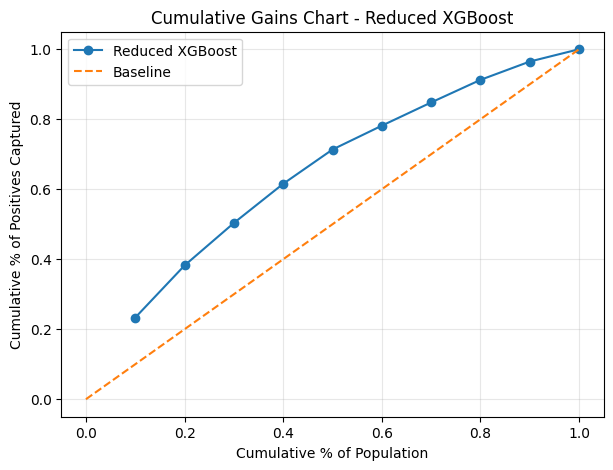

In [214]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    xgb_reduced_decile_summary["cum_population_pct"],
    xgb_reduced_decile_summary["cum_positive_pct"],
    marker="o",
    label="Reduced XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Baseline"
)

plt.xlabel("Cumulative % of Population")
plt.ylabel("Cumulative % of Positives Captured")
plt.title("Cumulative Gains Chart - Reduced XGBoost")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(f"{OUTPUTS_DIR}/figures/xgb_reduced_cumulative_chart.png", dpi=150, bbox_inches='tight')
plt.show()


In [178]:
lift_compare_df = pd.DataFrame({
    "decile": xgb_decile_summary["decile"].astype(str),
    "full_xgb_lift": xgb_decile_summary["lift"].values,
    "reduced_xgb_lift": xgb_reduced_decile_summary["lift"].values,
    "full_xgb_cum_capture": xgb_decile_summary["cum_positive_pct"].values,
    "reduced_xgb_cum_capture": xgb_reduced_decile_summary["cum_positive_pct"].values
})

display(lift_compare_df.round(4))

,decile,full_xgb_lift,reduced_xgb_lift,full_xgb_cum_capture,reduced_xgb_cum_capture
0,1,2.3952,2.3321,0.2396,0.2333
1,2,1.4081,1.4893,0.3804,0.3822
2,3,1.2456,1.2140,0.5050,0.5036
3,4,1.1283,1.1192,0.6178,0.6155
4,5,0.9026,0.9793,0.7080,0.7134
5,6,0.7447,0.6815,0.7825,0.7816
6,7,0.6589,0.6634,0.8484,0.8479
7,8,0.6454,0.6454,0.9129,0.9125
8,9,0.4964,0.5235,0.9625,0.9648
9,10,0.3744,0.3518,1.0000,1.0000


### Key Observations
The top decile lift remains very similar between the two models:
Full model: 2.39
Reduced model: 2.33

This indicates that both models identify high-risk patients with nearly identical effectiveness.


The cumulative capture of positives in the top 20% of the population is almost unchanged:
Full model: 38.0%
Reduced model: 38.2%

This shows that the reduced model is equally effective in capturing a large proportion of readmissions within a small subset of patients.

Across all deciles, the lift and cumulative gains curves closely track each other, with only minor variations that are not materially significant.

Interpretation

The reduced model maintains comparable ranking performance to the full model, despite using fewer features. This confirms that the features removed during the SHAP-guided reduction step contributed little to the model’s ability to distinguish high-risk patients.

From a business perspective, this means:

The model can prioritize high-risk patients just as effectively
The reduced feature set improves simplicity, interpretability, and potential deployment efficiency
There is no meaningful loss in predictive power or decision-making capability

## Saving Models

In [195]:
joblib.dump(xgb_reduced, "models/xgb_reduced.joblib")
joblib.dump(best_xgb, "models/xgb_full.joblib")

['models/xgb_full.joblib']

In [196]:
import json

xgb_metadata = {
    "model_type": "XGBoost",
    "features_full": list(X_train.columns),
    "features_reduced": list(X_train_reduced.columns),
    "threshold_full": optimal_threshold_recall_xgb,
    "threshold_reduced": optimal_threshold_reduced,
    "objective": "maximize recall under precision constraint",
    "test_auc_full": 0.6675,
    "test_auc_reduced": 0.6673
}

with open("models/xgb_metadata.json", "w") as f:
    json.dump(xgb_metadata, f, indent=4)

In [203]:
import pandas as pd
import joblib
import json
import numpy as np

DATA_RAW_DIR

# active features from fitted lasso
lasso_active_features = X_train_scaled.columns[lasso_log_reg.coef_[0] != 0].tolist()

# reduced datasets
X_train_lasso_reduced = X_train_scaled[lasso_active_features].copy()
X_test_lasso_reduced = X_test_scaled[lasso_active_features].copy()

# save data
X_train_lasso_reduced.to_pickle(f"{PROCESSED_DIR}/X_train_lasso_reduced.pkl")
X_test_lasso_reduced.to_pickle(f"{PROCESSED_DIR}/X_test_lasso_reduced.pkl")

# optional: also save csv
X_train_lasso_reduced.to_csv(f"{PROCESSED_DIR}/X_train_lasso_reduced.csv", index=False)
X_test_lasso_reduced.to_csv(f"{PROCESSED_DIR}/X_test_lasso_reduced.csv", index=False)

# save feature list
joblib.dump(lasso_active_features, f"{PROCESSED_DIR}/lasso_active_features.joblib")

with open(f"{PROCESSED_DIR}/lasso_active_features.json", "w") as f:
    json.dump(lasso_active_features, f, indent=4)

print("Saved LASSO-reduced datasets")
print("Train shape:", X_train_lasso_reduced.shape)
print("Test shape:", X_test_lasso_reduced.shape)

Saved LASSO-reduced datasets
Train shape: (79538, 62)
Test shape: (19802, 62)


In [204]:
# save reduced XGBoost datasets
X_train_reduced.to_pickle(f"{PROCESSED_DIR}/X_train_xgb_reduced.pkl")
X_test_reduced.to_pickle(f"{PROCESSED_DIR}/X_test_xgb_reduced.pkl")

# optional csv
X_train_reduced.to_csv(f"{PROCESSED_DIR}/X_train_xgb_reduced.csv", index=False)
X_test_reduced.to_csv(f"{PROCESSED_DIR}/X_test_xgb_reduced.csv", index=False)

# save kept features
xgb_reduced_features = X_train_reduced.columns.tolist()
joblib.dump(xgb_reduced_features, f"{PROCESSED_DIR}/xgb_reduced_features.joblib")

with open(f"{PROCESSED_DIR}/xgb_reduced_features.json", "w") as f:
    json.dump(xgb_reduced_features, f, indent=4)

print("Saved SHAP-reduced XGBoost datasets")
print("Train shape:", X_train_reduced.shape)
print("Test shape:", X_test_reduced.shape)

Saved SHAP-reduced XGBoost datasets
Train shape: (79538, 69)
Test shape: (19802, 69)


In [205]:
processed_metadata = {
    "lasso_reduced_train_shape": X_train_lasso_reduced.shape,
    "lasso_reduced_test_shape": X_test_lasso_reduced.shape,
    "lasso_active_feature_count": len(lasso_active_features),
    "xgb_reduced_train_shape": X_train_reduced.shape,
    "xgb_reduced_test_shape": X_test_reduced.shape,
    "xgb_reduced_feature_count": X_train_reduced.shape[1]
}

with open(f"{PROCESSED_DIR}/processed_datasets_metadata.json", "w") as f:
    json.dump(processed_metadata, f, indent=4)

print("Saved processed dataset metadata")

Saved processed dataset metadata


## Fairness analysis

Eval dataframe shape: (19802, 5)

Race distribution in test set:
race
Caucasian          14886
AfricanAmerican     3707
Hispanic             371
Other                298
Asian                122
Name: count, dtype: int64

Gender distribution in test set:
gender
Female    10645
Male       9157
Name: count, dtype: int64

FAIRNESS ANALYSIS — BY RACE


,group,n_encounters,n_readmitted,readmission_rate,auc,recall,precision,f1,false_negative_rate,false_positive_rate
1,Caucasian,14886,1707,0.1147,0.6664,0.7229,0.1614,0.2639,0.2771,0.4865
0,AfricanAmerican,3707,396,0.1068,0.6562,0.6843,0.1518,0.2485,0.3157,0.4573
4,Hispanic,371,39,0.1051,0.7699,0.7436,0.2014,0.3169,0.2564,0.3464
2,Other,298,26,0.0872,0.7230,0.6538,0.1604,0.2576,0.3462,0.3272
3,Asian,122,10,0.0820,0.6696,0.7000,0.1400,0.2333,0.3000,0.3839



FAIRNESS ANALYSIS — BY GENDER


,group,n_encounters,n_readmitted,readmission_rate,auc,recall,precision,f1,false_negative_rate,false_positive_rate
1,Male,9157,1028,0.1123,0.6610,0.6800,0.1600,0.2590,0.3200,0.4515
0,Female,10645,1188,0.1116,0.6731,0.7382,0.1596,0.2625,0.2618,0.4882


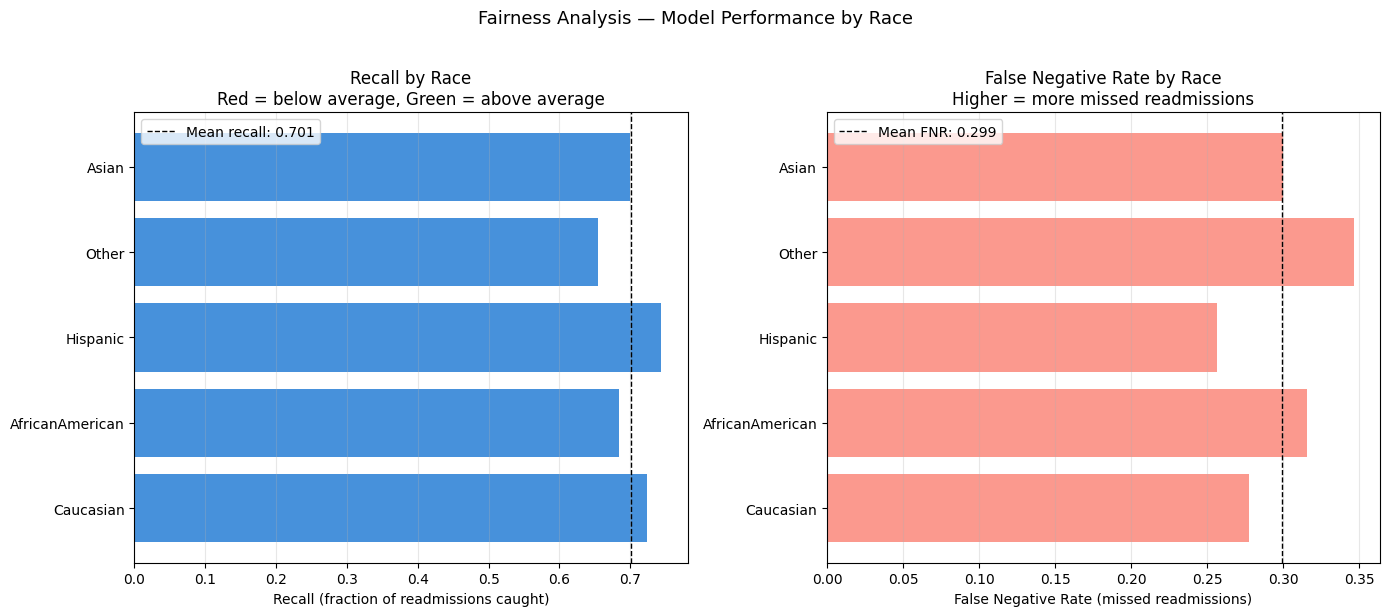


Disparate Impact Analysis:
Recall range across racial groups:
  Max recall: 0.744 (Hispanic)
  Min recall: 0.654 (Other)
  Range: 0.090

False Negative Rate range across racial groups:
  Max FNR: 0.346 (Other)
  Min FNR: 0.256 (Hispanic)


In [219]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    roc_auc_score, recall_score, 
    precision_score, f1_score
)
import matplotlib.pyplot as plt


y_prob_test = xgb_reduced.predict_proba(X_test_reduced)[:, 1]
y_pred_test = (y_prob_test >= optimal_threshold_reduced).astype(int)
y_test_array = y_test.values.ravel()

# Build evaluation dataframe
eval_df = pd.DataFrame({
    'y_true': y_test_array,
    'y_pred': y_pred_test,
    'y_prob': y_prob_test
})


eval_df['race'] = test_df.reset_index(drop=True)['race']
eval_df['gender'] = test_df.reset_index(drop=True)['gender']

print("Eval dataframe shape:", eval_df.shape)
print("\nRace distribution in test set:")
print(eval_df['race'].value_counts())
print("\nGender distribution in test set:")
print(eval_df['gender'].value_counts())

# ── Function to compute metrics by group ──────────────────────
def compute_group_metrics(df, group_col, min_samples=50):
    """
    Compute fairness metrics for each group.
    Groups with fewer than min_samples are excluded.
    """
    results = []
    
    for group in df[group_col].unique():
        subset = df[df[group_col] == group]
        
        if len(subset) < min_samples:
            continue
            
        n = len(subset)
        n_positive = subset['y_true'].sum()
        readmission_rate = subset['y_true'].mean()
        
        # Skip groups with no positive cases
        if n_positive == 0 or n_positive == n:
            continue
        
        # Model performance metrics
        auc = roc_auc_score(subset['y_true'], subset['y_prob'])
        recall = recall_score(subset['y_true'], subset['y_pred'], 
                            zero_division=0)
        precision = precision_score(subset['y_true'], subset['y_pred'],
                                  zero_division=0)
        f1 = f1_score(subset['y_true'], subset['y_pred'],
                     zero_division=0)
        
        # False negative rate — missed readmissions
        tp = ((subset['y_true'] == 1) & (subset['y_pred'] == 1)).sum()
        fn = ((subset['y_true'] == 1) & (subset['y_pred'] == 0)).sum()
        fp = ((subset['y_true'] == 0) & (subset['y_pred'] == 1)).sum()
        tn = ((subset['y_true'] == 0) & (subset['y_pred'] == 0)).sum()
        
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # missed readmissions
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # unnecessary flags
        
        results.append({
            'group': group,
            'n_encounters': n,
            'n_readmitted': int(n_positive),
            'readmission_rate': round(readmission_rate, 4),
            'auc': round(auc, 4),
            'recall': round(recall, 4),
            'precision': round(precision, 4),
            'f1': round(f1, 4),
            'false_negative_rate': round(fnr, 4),
            'false_positive_rate': round(fpr, 4),
        })
    
    return pd.DataFrame(results).sort_values('readmission_rate', 
                                              ascending=False)

# ── Run fairness analysis ──────────────────────────────────────
print("\n" + "="*60)
print("FAIRNESS ANALYSIS — BY RACE")
print("="*60)
race_metrics = compute_group_metrics(eval_df, 'race')
display(race_metrics)

print("\n" + "="*60)
print("FAIRNESS ANALYSIS — BY GENDER")
print("="*60)
gender_metrics = compute_group_metrics(eval_df, 'gender')
display(gender_metrics)

# ── Plot — Recall by race ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Recall by race
colors = ['#d32f2f' if r < race_metrics['recall'].mean() - 0.05
          else '#388e3c' if r > race_metrics['recall'].mean() + 0.05
          else '#1976d2'
          for r in race_metrics['recall']]

axes[0].barh(race_metrics['group'], race_metrics['recall'],
             color=colors, alpha=0.8)
axes[0].axvline(race_metrics['recall'].mean(), color='black',
                linestyle='--', linewidth=1,
                label=f"Mean recall: {race_metrics['recall'].mean():.3f}")
axes[0].set_xlabel('Recall (fraction of readmissions caught)')
axes[0].set_title('Recall by Race\nRed = below average, Green = above average')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# False negative rate by race
axes[1].barh(race_metrics['group'], 
             race_metrics['false_negative_rate'],
             color='salmon', alpha=0.8)
axes[1].axvline(race_metrics['false_negative_rate'].mean(),
                color='black', linestyle='--', linewidth=1,
                label=f"Mean FNR: {race_metrics['false_negative_rate'].mean():.3f}")
axes[1].set_xlabel('False Negative Rate (missed readmissions)')
axes[1].set_title('False Negative Rate by Race\nHigher = more missed readmissions')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Fairness Analysis — Model Performance by Race',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/figures/fairness_race.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Disparate impact check ─────────────────────────────────────
print("\nDisparate Impact Analysis:")
print("Recall range across racial groups:")
print(f"  Max recall: {race_metrics['recall'].max():.3f} "
      f"({race_metrics.loc[race_metrics['recall'].idxmax(), 'group']})")
print(f"  Min recall: {race_metrics['recall'].min():.3f} "
      f"({race_metrics.loc[race_metrics['recall'].idxmin(), 'group']})")
print(f"  Range: {race_metrics['recall'].max() - race_metrics['recall'].min():.3f}")

print("\nFalse Negative Rate range across racial groups:")
print(f"  Max FNR: {race_metrics['false_negative_rate'].max():.3f} "
      f"({race_metrics.loc[race_metrics['false_negative_rate'].idxmax(), 'group']})")
print(f"  Min FNR: {race_metrics['false_negative_rate'].min():.3f} "
      f"({race_metrics.loc[race_metrics['false_negative_rate'].idxmin(), 'group']})")

## Fairness Analysis — Model Performance Across Demographics

To ensure the model does not disproportionately disadvantage specific patient groups, performance was evaluated across race and gender using recall (true positive rate) and false negative rate (missed readmissions).

## Key Findings
The model demonstrates moderate fairness across racial groups, with:

Recall ranging from 65% to 74%

False negative rate ranging from 25% to 35%

Hispanic patients experience the best model performance:
    Highest recall (74%)
    Lowest false negative rate (25%)

Patients categorized as "Other" experience the weakest performance:
    Lowest recall (65%)
    Highest false negative rate (35%)

This indicates a higher likelihood of missed readmissions for this group

African American patients show slightly below-average recall and elevated false negative rates, suggesting mild underperformance relative to other groups

Results for Asian patients should be interpreted cautiously due to small sample size


### Gender Analysis

The model performs slightly better for female patients:

Recall: 73.8% (Female) vs 68.0% (Male)
False negative rate: 26.2% vs 32.0%

This suggests that male patients are more likely to have their readmission risk underestimated

### Interpretation
Overall, the model does not exhibit severe bias, but moderate disparities exist, particularly in:
Missed readmissions (false negatives)
Performance consistency across smaller demographic groups
These differences may arise from:
Underrepresentation of certain groups in the training data
Differences in healthcare utilization patterns
Feature limitations in capturing group-specific risk signals

### Final Takeaway
The model demonstrates reasonably consistent performance across demographic groups, but moderate disparities in false negative rates indicate a risk of unequal patient prioritization. These findings highlight the importance of monitoring fairness in deployment and considering mitigation strategies if the model is used in clinical decision-making.

### Limitations and Recommendations

**Sample size constraints** limit reliable fairness
conclusions for Asian, Other, and Hispanic subgroups.
A larger dataset or oversampling of underrepresented
groups would be required for robust subgroup performance
estimation.

**Recommended actions for production deployment:**

1. Monitor recall and false negative rate by racial group
   in production - flag if disparities exceed 10 percentage
   points
2. Investigate feature engineering improvements specifically
   for male patients - the 5.8 pp recall gap suggests
   systematic differences in how male readmission risk
   is captured
3. Collect larger samples of underrepresented racial groups
   to enable reliable fairness assessment
4. Consider group-specific threshold calibration if
   disparities persist at scale


# FINAL MODEL COMPARISON TABLE

In [191]:
lasso_coef = lasso_log_reg.coef_

n_lasso_features = np.sum(lasso_coef != 0)

print("Active Lasso features:", n_lasso_features)

Active Lasso features: 62


In [215]:
def extract_test_metrics(df):
    test_row = df[df['Split'] == 'Test'].iloc[0]
    return {
        'Test AUC': test_row['ROC_AUC'],
        'Test Recall': test_row['Recall'],
        'Test Precision': test_row['Precision'],
        'Test F1': test_row['F1'],
    }

# ── Extract metrics ───────────────────────────────────────────
baseline_metrics = extract_test_metrics(balanced_train_test_df)
lasso_metrics = extract_test_metrics(lasso_train_test_df)
xgb_full_metrics = extract_test_metrics(xgb_full_results)
xgb_baseline_metrics=extract_test_metrics(xgb_train_test_df)
xgb_reduced_metrics = extract_test_metrics(xgb_reduced_results)

# ── Build final table ─────────────────────────────────────────
model_comparison = pd.DataFrame([
    {
        'Model': 'Balanced Logistic Regression',
        'Threshold': 0.50,
        'Features': X_train.shape[1],
        **baseline_metrics,
        #'KS Statistic': '-'  # if not computed
    },
    {
        'Model': 'Lasso Logistic Regression',
        'Threshold': 0.50,
        'Features': n_lasso_features,
        **lasso_metrics,
        #'KS Statistic': ks_lasso  # if you computed
    },
    
     {
        'Model': 'XGBoost Baseline',
        'Threshold': 0.5,
        'Features': X_train.shape[1],
        **xgb_baseline_metrics,
        #'KS Statistic': ks_xgb_full if 'ks_xgb_full' in globals() else '-'
    },


    {
        'Model': 'XGBoost Tuned',
        'Threshold': optimal_threshold_recall_xgb,
        'Features': X_train.shape[1],
        **xgb_full_metrics,
        #'KS Statistic': ks_xgb_full if 'ks_xgb_full' in globals() else '-'
    },
    {
        'Model': 'XGBoost Reduced',
        'Threshold': optimal_threshold_reduced,
        'Features': X_train_reduced.shape[1],
        **xgb_reduced_metrics,
        #'KS Statistic': ks_xgb_reduced if 'ks_xgb_reduced' in globals() else '-'
    }
])

# ── Formatting ────────────────────────────────────────────────
model_comparison = model_comparison.round(4)

dfi.export(
    model_comparison.round(3),
    f'{OUTPUTS_DIR}/tables/final_models_comparison.png',
    dpi=150, 
    table_conversion='matplotlib'
)

display(model_comparison)

,Model,Threshold,Features,Test AUC,Test Recall,Test Precision,Test F1
0,Balanced Logistic Regression,0.50,79,0.6617,0.5618,0.1751,0.2670
1,Lasso Logistic Regression,0.50,62,0.6618,0.5632,0.1763,0.2685
2,XGBoost Baseline,0.50,79,0.6607,0.5745,0.1775,0.2712
3,XGBoost Tuned,0.44,79,0.6675,0.7225,0.1561,0.2567
4,XGBoost Reduced,0.45,69,0.6673,0.7112,0.1598,0.2609
